# Zeitreihenbasierte Analyse der Dynamik von Finanzkennzahlen
**Masterarbeit – Tobias Mourier, TH Wildau, 2026**

---

## 00 – Setup & Datenübersicht

Dieses Notebook arbeitet ausschließlich mit den vorberechneten CSVs aus der `src/`-Pipeline.  
Die Methodik ist in den `.py`-Modulen dokumentiert – hier wird analysiert und visualisiert.

In [1]:
# ── Imports ──
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.figsize': (12, 4), 'font.size': 10})

# ── Pfade ──
PROJECT = Path('.').resolve()
if PROJECT.name == 'notebooks':  # falls aus Unterordner gestartet
    PROJECT = PROJECT.parent
OUT = PROJECT / 'output'
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f'Projekt: {PROJECT}')
print(f'Output:  {OUT}')

Projekt: /Users/tobi/Documents/GitHub/Zeitreihenanalyse Finanzkennzahlen
Output:  /Users/tobi/Documents/GitHub/Zeitreihenanalyse Finanzkennzahlen/output


### 00.1 – Alle Datenquellen laden

In [2]:
# ── Zentrale Daten laden ──
panel       = pd.read_csv(OUT / 'ratios' / 'ratio_panel.csv')
ar_features = pd.read_csv(OUT / 'ar' / 'ar_features.csv')
ar_all       = pd.read_csv(OUT / 'ar' / 'ar_features_all.csv')  # Multi-Model
quadrants   = pd.read_csv(OUT / 'clustering' / 'quadrant_assignments.csv')
validation  = pd.read_csv(OUT / 'external_validation' / 'validation_features.csv')

# K-Means Labels
kmeans_ar   = pd.read_csv(OUT / 'clustering' / 'kmeans_ar_dynamics_labels.csv')
kmeans_full = pd.read_csv(OUT / 'clustering' / 'kmeans_ar_plus_levels_labels.csv')

# Interdependenz
corr_phi1   = pd.read_csv(OUT / 'interdependence' / 'corr_phi1.csv', index_col=0)
corr_sigma  = pd.read_csv(OUT / 'interdependence' / 'corr_sigma.csv', index_col=0)
crosstabs   = pd.read_csv(OUT / 'interdependence' / 'quadrant_crosstabs.csv')

# Explore
vol_scores  = pd.read_csv(OUT / 'explore' / 'volatility_scores.csv')
peak_windows = pd.read_csv(OUT / 'explore' / 'peak_windows.csv')

# Kennzahl-Namen aus config importieren
from config import RATIOS, RATIO_NAMES, RAW_COLS, EXPECTED_QUARTERS
from config import YEAR_START, YEAR_END, EXCLUDED_SECTORS

RATIO_LABELS = {r.name: r.label for r in RATIOS}
RATIO_CATS   = {r.name: r.category for r in RATIOS}

print(f'Daten geladen. Panel: {panel.shape}, AR: {ar_features.shape}, AR-all: {ar_all.shape}, Validation: {validation.shape}')

Daten geladen. Panel: (93200, 9), AR: (6521, 13), AR-all: (26084, 14), Validation: (932, 17)


### 00.2 – Stichproben-Trichter

Transparenz über jeden Filterschritt: Wie viele Unternehmen fallen jeweils raus?

In [3]:
from config import RAW_BALANCE, RAW_INCOME, RAW_CASHFLOW, RAW_PROFILE
from config import PROFILE_SECTOR_COL

# Ticker-Universum rekonstruieren (ohne Pipeline neu zu laufen)
tickers_balance  = {p.stem for p in RAW_BALANCE.glob('*.csv')}
tickers_income   = {p.stem for p in RAW_INCOME.glob('*.csv')}
tickers_cashflow = {p.stem for p in RAW_CASHFLOW.glob('*.csv')}
tickers_all      = tickers_balance & tickers_income & tickers_cashflow

# Sektor-Map laden
sector_map = {}
for csv_path in RAW_PROFILE.glob('*.csv'):
    try:
        df_tmp = pd.read_csv(csv_path, usecols=['symbol', PROFILE_SECTOR_COL])
        if len(df_tmp) > 0:
            sector_map[df_tmp['symbol'].iloc[0]] = str(df_tmp[PROFILE_SECTOR_COL].iloc[0])
    except Exception:
        pass

tickers_after_sector = {t for t in tickers_all if sector_map.get(t, '') not in EXCLUDED_SECTORS}
tickers_final = set(panel['ticker'].unique())

excluded_counts = pd.Series({
    s: sum(1 for t in tickers_all if sector_map.get(t) == s)
    for s in EXCLUDED_SECTORS
}).sort_values(ascending=False)

print('═' * 55)
print('  STICHPROBEN-TRICHTER')
print('═' * 55)
print(f'  Rohdaten (Schnittmenge 3 Quellen):  {len(tickers_all):>5}')
print(f'  − Finanzsektor exkludiert:          {len(tickers_all) - len(tickers_after_sector):>5}')
for s, n in excluded_counts.items():
    print(f'      {s}: {n}')
print(f'  = Nach Sektor-Filter:               {len(tickers_after_sector):>5}')
print(f'  − Unvollständig (< 100 Quartale):   {len(tickers_after_sector) - len(tickers_final):>5}')
print(f'  = Finale Stichprobe:                {len(tickers_final):>5}')
print(f'\n  Zeitraum: Q1/{YEAR_START} – Q4/{YEAR_END} = {EXPECTED_QUARTERS} Quartale')
print(f'  Vollständigkeit: 100% (kein einziges fehlendes Quartal erlaubt)')

═══════════════════════════════════════════════════════
  STICHPROBEN-TRICHTER
═══════════════════════════════════════════════════════
  Rohdaten (Schnittmenge 3 Quellen):   5871
  − Finanzsektor exkludiert:            883
      Financial Services: 883
      Insurance: 0
      Banks: 0
  = Nach Sektor-Filter:                4988
  − Unvollständig (< 100 Quartale):    4056
  = Finale Stichprobe:                  932

  Zeitraum: Q1/2000 – Q4/2024 = 100 Quartale
  Vollständigkeit: 100% (kein einziges fehlendes Quartal erlaubt)


### 00.3 – Ratio Panel: Datenqualität

NaN-Raten pro Kennzahl, deskriptive Statistik und Winsorisierungs-Transparenz.

In [4]:
# ── NaN-Raten pro Kennzahl ──
n_total = len(panel)
nan_stats = pd.DataFrame({
    'Kennzahl': RATIO_NAMES,
    'Label': [RATIO_LABELS[r] for r in RATIO_NAMES],
    'Kategorie': [RATIO_CATS[r] for r in RATIO_NAMES],
    'NaN': [panel[r].isna().sum() for r in RATIO_NAMES],
    'NaN %': [round(panel[r].isna().mean() * 100, 2) for r in RATIO_NAMES],
    'Gültig': [panel[r].notna().sum() for r in RATIO_NAMES],
})
print(f'Panel: {panel["ticker"].nunique()} Ticker × {panel["quarter"].nunique()} Quartale = {n_total:,} Zeilen\n')
display(nan_stats)

Panel: 932 Ticker × 100 Quartale = 93,200 Zeilen



,Kennzahl,Label,Kategorie,NaN,NaN %,Gültig
0,ROA,Return on Assets,Profitabilität,53,0.0600,93147
1,ROE,Return on Equity,Profitabilität,97,0.1000,93103
2,EBIT_margin,EBIT-Marge,Profitabilität,89,0.1000,93111
3,fcf_margin,Free-Cashflow-Marge,Profitabilität,120,0.1300,93080
4,current_ratio,Current Ratio,Liquidität,141,0.1500,93059
5,debt_to_equity,Debt-to-Equity,Kapitalstruktur,5753,6.1700,87447
6,equity_ratio,Eigenkapitalquote,Kapitalstruktur,96,0.1000,93104


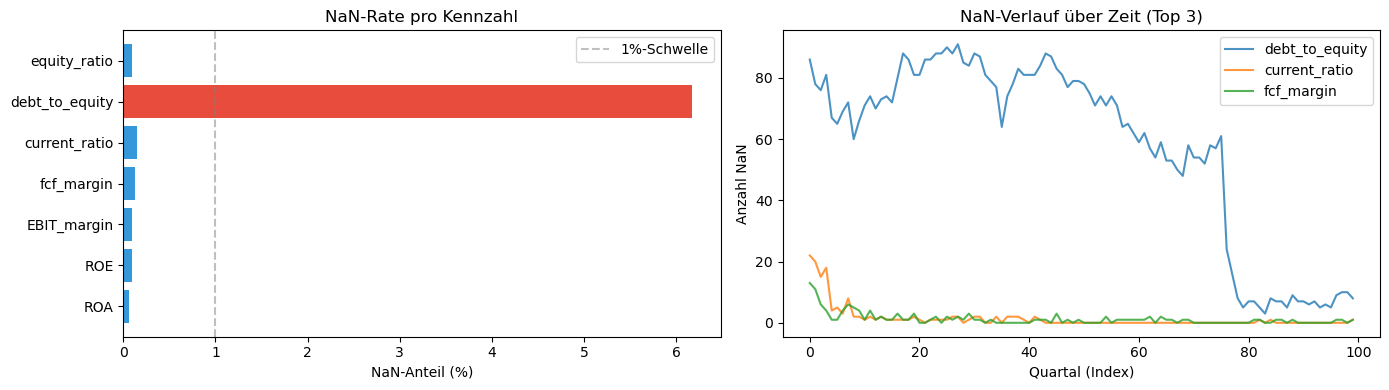

In [5]:
# ── NaN-Ursachen: Welche Quartale und Ticker sind betroffen? ──
# NaN entsteht durch fehlende Felder in den Quell-CSVs (z.B. kein shortLongTermDebtTotal)
# oder durch Division durch 0 (Nenner = 0 → NaN). Die Quelldaten haben 100 Quartale,
# aber einzelne Bilanzpositionen können trotzdem leer sein.

nan_by_quarter = panel.set_index('quarter')[RATIO_NAMES].isna().groupby('quarter').sum()
top_nan_ratios = nan_stats.nlargest(3, 'NaN %')[['Kennzahl', 'NaN %']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Links: NaN-Rate pro Kennzahl
colors = ['#e74c3c' if v > 1 else '#3498db' for v in nan_stats['NaN %']]
axes[0].barh(nan_stats['Kennzahl'], nan_stats['NaN %'], color=colors)
axes[0].set_xlabel('NaN-Anteil (%)')
axes[0].set_title('NaN-Rate pro Kennzahl')
axes[0].axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='1%-Schwelle')
axes[0].legend()

# Rechts: NaN über Zeit (nur die problematischsten Kennzahlen)
for ratio in top_nan_ratios['Kennzahl']:
    vals = nan_by_quarter[ratio]
    axes[1].plot(range(len(vals)), vals.values, label=ratio, alpha=0.8)
axes[1].set_xlabel('Quartal (Index)')
axes[1].set_ylabel('Anzahl NaN')
axes[1].set_title('NaN-Verlauf über Zeit (Top 3)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# ── Deskriptive Statistik (nach Outlier-Bereinigung) ──
desc = panel[RATIO_NAMES].describe().T.round(4)
desc.index.name = 'Kennzahl'
display(desc)

,count,mean,std,min,25%,50%,75%,max
Kennzahl,,,,,,,,
ROA,93147.0000,0.0121,0.0262,-0.1217,0.0048,0.0126,0.0229,0.0859
ROE,93103.0000,0.0292,0.1057,-0.5388,0.0123,0.0302,0.0516,0.5389
EBIT_margin,93111.0000,0.0868,0.4003,-3.0298,0.0505,0.1134,0.1965,0.8210
fcf_margin,93080.0000,0.0115,0.4477,-3.2963,-0.0191,0.0610,0.1500,0.7652
current_ratio,93059.0000,2.2281,2.0558,0.1676,1.0989,1.6435,2.5770,13.7994
debt_to_equity,87447.0000,0.9555,2.1990,-9.1842,0.3007,0.6585,1.1888,14.0606
equity_ratio,93104.0000,0.4344,0.2135,-0.2317,0.3028,0.4282,0.5685,0.9031


### 00.4 – Datenbereinigung: Rolling-Window Outlier Detection

Die Bereinigung erfolgt **auf Rohwert-Ebene** (vor Kennzahlenberechnung) per Rolling-Window-Verfahren (vgl. `load_data.py`):  
- Gleitende Fenster der Breite 8 Quartale (2 Jahre)  
- Innerhalb jedes Fensters: Median und STDEV.P  
- Flagging wenn |Wert − Median| > 3 × Std  
- Korrektur: Ersatz durch Fenster-Median

In [7]:
# ── Outlier-Report: Zusammenfassung ──
outlier_report = pd.read_csv(OUT / 'preprocessing' / 'outlier_report.csv')

print(f'Outlier Detection: {len(outlier_report)} Korrekturen insgesamt\n')

# Korrekturen pro Rohwert-Spalte
corr_per_col = (
    outlier_report.groupby('column')
    .agg(n_korrekturen=('ticker', 'size'),
         n_ticker=('ticker', 'nunique'))
    .sort_values('n_korrekturen', ascending=False)
)
corr_per_col['pct_ticker'] = (corr_per_col['n_ticker'] / panel['ticker'].nunique() * 100).round(1)
corr_per_col.index.name = 'Rohwert-Spalte'
display(corr_per_col)

Outlier Detection: 606 Korrekturen insgesamt



,n_korrekturen,n_ticker,pct_ticker
Rohwert-Spalte,,,
netIncome,233,193,20.7000
ebit,193,162,17.4000
totalRevenue,43,32,3.4000
totalCurrentLiabilities,41,37,4.0000
freeCashFlow,34,30,3.2000
totalCurrentAssets,26,20,2.1000
shortLongTermDebtTotal,25,19,2.0000
totalStockholderEquity,8,7,0.8000
totalAssets,3,3,0.3000


### 00.5 – Null-Werte (0) in Rohwerten

Wie häufig sind exakte Nullen in den Basisgrößen der Kennzahlenberechnung?  
Relevanz: **0 im Nenner → NaN** (Division durch Null), **0 im Zähler → Ratio = 0** (inhaltlich korrekt oder Datenlücke?).  
Besonders `shortLongTermDebtTotal` = 0 kann bedeuten: Unternehmen ist schuldenfrei *oder* Wert fehlt in der API.

In [8]:
# ── Null-Werte (0) und NaN in Rohwerten ──
raw_panel = pd.read_csv(OUT / 'ratios' / 'raw_values_panel.csv')

from config import RAW_COLS

n_total = len(raw_panel)
n_tickers = raw_panel['ticker'].nunique()

zero_stats = []
for col in RAW_COLS:
    is_zero = (raw_panel[col] == 0)
    is_nan  = raw_panel[col].isna()
    is_either = is_zero | is_nan
    tickers_zero   = raw_panel.loc[is_zero, 'ticker'].nunique()
    tickers_nan    = raw_panel.loc[is_nan, 'ticker'].nunique()
    tickers_either = raw_panel.loc[is_either, 'ticker'].nunique()

    zero_stats.append({
        'Spalte': col,
        'Nullen (0)': is_zero.sum(),
        '% Zeilen': round(is_zero.sum() / n_total * 100, 2),
        'Ticker mit ≥1 Null': tickers_zero,
        'NaN': is_nan.sum(),
        'Ticker mit ≥1 NaN': tickers_nan,
        'Ticker betroffen (0 oder NaN)': tickers_either,
        '% Ticker betroffen': round(tickers_either / n_tickers * 100, 1),
    })

df_zeros = pd.DataFrame(zero_stats).sort_values('Nullen (0)', ascending=False)
print(f'Rohwerte-Panel: {n_tickers} Ticker × {raw_panel["quarter"].nunique()} Quartale = {n_total:,} Zeilen\n')
display(df_zeros.reset_index(drop=True))

Rohwerte-Panel: 1006 Ticker × 100 Quartale = 100,600 Zeilen



,Spalte,Nullen (0),% Zeilen,Ticker mit ≥1 Null,NaN,Ticker mit ≥1 NaN,Ticker betroffen (0 oder NaN),% Ticker betroffen
0,ebit,609,0.6100,71,443,44,103,10.2000
1,totalRevenue,355,0.3500,22,77,14,27,2.7000
2,totalCurrentAssets,109,0.1100,13,952,81,93,9.2000
3,totalCurrentLiabilities,62,0.0600,7,448,52,56,5.6000
4,netIncome,50,0.0500,16,56,6,22,2.2000
5,shortLongTermDebtTotal,17,0.0200,6,7429,324,324,32.2000
6,totalAssets,3,0.0000,1,192,30,30,3.0000
7,totalStockholderEquity,1,0.0000,1,284,57,58,5.8000
8,freeCashFlow,1,0.0000,1,1148,75,76,7.6000


In [9]:
# ── NaN-Qualitätsfilter: entfernte Ticker ──
from config import RATIOS, NAN_MAX_QUARTERS

den_cols = list({r.denominator_col for r in RATIOS})
num_cols = list({r.numerator_col for r in RATIOS} - {'shortLongTermDebtTotal'})

rows = []
for ticker, group in raw_panel.groupby('ticker'):
    reasons = []
    for col in den_cols:
        n = ((group[col] == 0) | group[col].isna()).sum()
        if n > NAN_MAX_QUARTERS:
            reasons.append(f'{col}: {n}Q (Nenner)')
    for col in num_cols:
        n = group[col].isna().sum()
        if n > NAN_MAX_QUARTERS:
            reasons.append(f'{col}: {n}Q (Zähler-NaN)')
    if reasons:
        rows.append({'ticker': ticker, 'Grund (Spalte: Quartale)': ', '.join(reasons)})

df_removed = pd.DataFrame(rows)
print(f'NaN-Qualitätsfilter: {len(df_removed)} Ticker entfernt (Schwelle: >{NAN_MAX_QUARTERS} fehlende Quartale)')
print(f'Verbleibend: {raw_panel["ticker"].nunique() - len(df_removed)} Ticker\n')
display(df_removed)

NaN-Qualitätsfilter: 53 Ticker entfernt (Schwelle: >10 fehlende Quartale)
Verbleibend: 953 Ticker



,ticker,Grund (Spalte: Quartale)
0,ASM,totalRevenue: 34Q (Nenner)
1,ATLCY,"totalCurrentLiabilities: 12Q (Nenner), freeCas..."
2,BAYRY,ebit: 13Q (Zähler-NaN)
3,BDNNY,ebit: 14Q (Zähler-NaN)
4,BTGOF,freeCashFlow: 12Q (Zähler-NaN)
5,CDP,"totalCurrentLiabilities: 33Q (Nenner), totalCu..."
6,CDPYF,totalCurrentLiabilities: 22Q (Nenner)
7,CHKP,ebit: 11Q (Zähler-NaN)
8,CSPKY,"totalAssets: 44Q (Nenner), totalCurrentLiabili..."
9,DASTY,totalCurrentLiabilities: 22Q (Nenner)


### 00.6 – Interaktive Zeitreihen-Prüfung

Visueller Einzelfallcheck: Ticker per Textsuche auswählen, Rohwerte und/oder Kennzahlen
anzeigen lassen – jeweils **vor** und **nach** Outlier-Bereinigung.
Erkannte Ausreißer werden als rote Marker hervorgehoben.

In [ ]:
# ── Interaktive Zeitreihen-Prüfung ──
import sys
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Pfade (Fallback, falls Setup-Zelle nicht ausgeführt)
if 'OUT' not in globals():
    _proj = Path('.').resolve()
    if _proj.name == 'notebooks':
        _proj = _proj.parent
    OUT = _proj / 'output'
    SRC = _proj / 'src'
    if str(SRC) not in sys.path:
        sys.path.insert(0, str(SRC))
if 'RAW_COLS' not in globals():
    from config import RATIOS, RATIO_NAMES, RAW_COLS
    RATIO_LABELS = {r.name: r.label for r in RATIOS}

# Daten laden
_raw_before = pd.read_csv(OUT / 'ratios' / 'raw_values_panel.csv')
_outlier_rpt = pd.read_csv(OUT / 'preprocessing' / 'outlier_report.csv')

# Bereinigtes Panel: Rohwerte aus load_data neu berechnen (nach Korrektur)
# Wir rekonstruieren die bereinigten Rohwerte, indem wir die Korrekturen anwenden
_raw_after = _raw_before.copy()
for _, row in _outlier_rpt[_outlier_rpt['was_corrected']].iterrows():
    mask = (_raw_after['ticker'] == row['ticker']) & (_raw_after['quarter'] == row['quarter'])
    _raw_after.loc[mask, row['column']] = row['corrected_value']

# Kennzahlen vor/nach berechnen (inline, ohne import von load_data)
_ratio_defs = {
    'ROA':          ('netIncome',      'totalAssets'),
    'ROE':          ('netIncome',      'totalStockholderEquity'),
    'EBIT_margin':  ('ebit',           'totalRevenue'),
    'fcf_margin':   ('freeCashFlow',   'totalRevenue'),
    'current_ratio':('totalCurrentAssets','totalCurrentLiabilities'),
    'debt_to_equity':('shortLongTermDebtTotal','totalStockholderEquity'),
    'equity_ratio': ('totalStockholderEquity','totalAssets'),
}

def _add_ratios(df):
    df = df.copy()
    for name, (num, den) in _ratio_defs.items():
        df[name] = df[num] / df[den].replace(0, np.nan)
    return df

_panel_before = _add_ratios(_raw_before)
_panel_after  = _add_ratios(_raw_after)

# Alle verfügbaren Spalten
_all_cols = RAW_COLS + RATIO_NAMES
# Nur Ticker, die den NaN-Qualitätsfilter bestanden haben
_valid_tickers = set(pd.read_csv(OUT / 'ratios' / 'ratio_panel.csv')['ticker'].unique())
_tickers_sorted = sorted(t for t in _raw_before['ticker'].unique() if t in _valid_tickers)

# Outlier-Lookup: {(ticker, quarter, column)} für schnelle Markierung
_outlier_set = set(zip(_outlier_rpt['ticker'], _outlier_rpt['quarter'], _outlier_rpt['column']))
_override_set = set(zip(
    _outlier_rpt[~_outlier_rpt['was_corrected']]['ticker'],
    _outlier_rpt[~_outlier_rpt['was_corrected']]['quarter'],
    _outlier_rpt[~_outlier_rpt['was_corrected']]['column'],
))

# ── Widgets ──
_w_search = widgets.Text(
    value='', placeholder='Ticker suchen...', description='Suche:',
    layout=widgets.Layout(width='250px'),
)
_w_ticker = widgets.Select(
    options=_tickers_sorted, rows=12, description='Ticker:',
    layout=widgets.Layout(width='250px'),
)
_w_raw = widgets.SelectMultiple(
    options=RAW_COLS, value=[], description='Rohwerte:',
    rows=len(RAW_COLS),
    layout=widgets.Layout(width='300px'),
)
_w_ratios = widgets.SelectMultiple(
    options=RATIO_NAMES, value=['ROA'], description='Kennzahlen:',
    rows=len(RATIO_NAMES),
    layout=widgets.Layout(width='300px'),
)
_btn_all_raw = widgets.Button(description='Alle Rohwerte', layout=widgets.Layout(width='140px'))
_btn_all_ratios = widgets.Button(description='Alle Kennzahlen', layout=widgets.Layout(width='140px'))
_btn_clear = widgets.Button(description='Auswahl leeren', layout=widgets.Layout(width='140px'))

def _toggle_all_raw(_):
    _w_raw.value = list(RAW_COLS) if len(_w_raw.value) < len(RAW_COLS) else []
def _toggle_all_ratios(_):
    _w_ratios.value = list(RATIO_NAMES) if len(_w_ratios.value) < len(RATIO_NAMES) else []
def _clear_all(_):
    _w_raw.value = []
    _w_ratios.value = []

_btn_all_raw.on_click(_toggle_all_raw)
_btn_all_ratios.on_click(_toggle_all_ratios)
_btn_clear.on_click(_clear_all)

_w_output = widgets.Output(layout=widgets.Layout(width='100%'))

# Textsuche → Ticker-Liste filtern
def _on_search(change):
    query = change['new'].upper()
    filtered = [t for t in _tickers_sorted if query in t]
    _w_ticker.options = filtered if filtered else _tickers_sorted
    if filtered:
        _w_ticker.value = filtered[0]

_w_search.observe(_on_search, names='value')

# Plot-Funktion
def _plot_timeseries(change=None):
    _w_output.clear_output(wait=True)
    with _w_output:
        ticker = _w_ticker.value
        cols = list(_w_raw.value) + list(_w_ratios.value)
        if not ticker or not cols:
            print('Bitte Ticker und mindestens eine Spalte auswählen.')
            return

        before = _panel_before[_panel_before['ticker'] == ticker].copy()
        after  = _panel_after[_panel_after['ticker'] == ticker].copy()
        if before.empty:
            print(f'Kein Daten für {ticker}')
            return

        quarters = before['quarter'].values
        x = np.arange(len(quarters))

        n_cols = len(cols)
        fig, axes = plt.subplots(n_cols, 1, figsize=(14, 3.5 * n_cols), squeeze=False)
        fig.suptitle(f'{ticker} – Zeitreihen (vor/nach Bereinigung)', fontsize=13, y=1.01)

        for i, col in enumerate(cols):
            ax = axes[i, 0]
            y_before = before[col].values.astype(float)
            y_after  = after[col].values.astype(float)

            # Linien
            ax.plot(x, y_before, color='#BBBBBB', linewidth=1.2, label='Original', zorder=1)
            ax.plot(x, y_after, color='#1976D2', linewidth=1.5, label='Bereinigt', zorder=2)

            # Outlier-Marker
            for j, q in enumerate(quarters):
                if (ticker, q, col) in _outlier_set:
                    if (ticker, q, col) in _override_set:
                        ax.scatter(j, y_before[j], color='#4CAF50', marker='^',
                                   s=80, zorder=4)
                    else:
                        ax.scatter(j, y_before[j], color='#E53935', marker='o',
                                   s=60, zorder=3)

            # Achsen
            label = RATIO_LABELS.get(col, col)
            ax.set_ylabel(label, fontsize=10)
            ax.set_xticks(x[::4])
            ax.set_xticklabels(quarters[::4], rotation=45, ha='right', fontsize=8)
            ax.grid(True, alpha=0.3)

            # Legende (einmalig korrekt)
            handles = [
                plt.Line2D([0],[0], color='#BBBBBB', lw=1.2, label='Original'),
                plt.Line2D([0],[0], color='#1976D2', lw=1.5, label='Bereinigt'),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#E53935',
                           markersize=8, label='Outlier (korrigiert)'),
            ]
            # Override in Legende nur wenn vorhanden
            has_override = any((ticker, q, col) in _override_set for q in quarters)
            if has_override:
                handles.append(plt.Line2D([0],[0], marker='^', color='w',
                               markerfacecolor='#4CAF50', markersize=8, label='Override (beibehalten)'))
            ax.legend(handles=handles, loc='upper right', fontsize=8)

        plt.tight_layout()
        plt.show()

        # Info: Outlier-Details für diesen Ticker
        rpt = _outlier_rpt[(_outlier_rpt['ticker'] == ticker) & (_outlier_rpt['column'].isin(cols))]
        if not rpt.empty:
            print(f'\n── Outlier-Report für {ticker} ({len(rpt)} Einträge) ──')
            display(rpt[['quarter','column','original_value','corrected_value',
                         'flag_count','was_corrected','isolation_score',
                         'cross_metric_flagged']].reset_index(drop=True))
        else:
            print(f'\nKeine Outlier für {ticker} in den gewählten Spalten.')

_w_ticker.observe(_plot_timeseries, names='value')
_w_raw.observe(_plot_timeseries, names='value')
_w_ratios.observe(_plot_timeseries, names='value')

# Layout
_left = widgets.VBox([_w_search, _w_ticker], layout=widgets.Layout(width='260px'))
_mid = widgets.VBox([widgets.Label('Rohwerte:'), _w_raw, _btn_all_raw],
                     layout=widgets.Layout(width='310px'))
_right = widgets.VBox([widgets.Label('Kennzahlen:'), _w_ratios, _btn_all_ratios],
                       layout=widgets.Layout(width='310px'))
_buttons = widgets.HBox([_btn_clear], layout=widgets.Layout(margin='5px 0'))
_controls = widgets.HBox([_left, _mid, _right])

display(_controls, _buttons, _w_output)
_plot_timeseries()  # Initialer Plot

Output(layout=Layout(width='100%'))

### 00.7 – AR-Features: Übersicht

In [11]:
# ── AR(1)-Schätzungen: Qualitätsprüfung ──
# Vollständigkeit und Erfolgsrate der Schätzungen.
# Inhaltliche Interpretation der φ₁-Werte → Abschnitt 01 (FF1)

ar_overview = ar_features.groupby('ratio').agg(
    n=('ticker', 'count'),
    phi1_mean=('phi1', 'mean'),
    phi1_median=('phi1', 'median'),
    phi1_std=('phi1', 'std'),
    phi1_signif=('phi1_pval', lambda x: (x < 0.05).mean() * 100),
    sigma_mean=('sigma_diff', 'mean'),
    sigma_median=('sigma_diff', 'median'),
    halflife_available=('half_life', lambda x: x.notna().mean() * 100),
).round(4)
ar_overview.columns = ['N', 'φ₁ Mean', 'φ₁ Median', 'φ₁ Std', 'φ₁ signif. %',
                        'σ Mean', 'σ Median', 'Half-Life verfügbar %']

print(f'AR(1) auf ΔY: {len(ar_features)} Schätzungen ({ar_features["ticker"].nunique()} Ticker × {ar_features["ratio"].nunique()} Kennzahlen)\n')
print('Hinweis: Half-Life nur berechenbar wenn 0 < φ₁ < 1 (Mean-Reversion)\n')
display(ar_overview)

AR(1) auf ΔY: 6521 Schätzungen (932 Ticker × 7 Kennzahlen)

Hinweis: Half-Life nur berechenbar wenn 0 < φ₁ < 1 (Mean-Reversion)



,N,φ₁ Mean,φ₁ Median,φ₁ Std,φ₁ signif. %,σ Mean,σ Median,Half-Life verfügbar %
ratio,,,,,,,,
EBIT_margin,932,-0.4007,-0.4309,0.1554,89.8069,0.1823,0.1107,98.2833
ROA,931,-0.4133,-0.4315,0.1389,92.1590,0.0193,0.0166,99.5704
ROE,931,-0.4039,-0.4274,0.1509,90.0107,0.0788,0.0480,98.9259
current_ratio,932,-0.1855,-0.1737,0.1588,45.6009,0.6001,0.3175,88.6266
debt_to_equity,931,-0.1123,-0.0894,0.1919,32.4382,0.7437,0.1658,71.8582
equity_ratio,932,-0.0530,-0.0398,0.1573,18.5622,0.0387,0.0314,64.2704
fcf_margin,932,-0.4586,-0.4586,0.1453,96.5665,0.2591,0.1654,99.6781


### 00.8 – Klassifikation: Quadranten & K-Means

In [12]:
# ── Quadranten-Verteilung pro Kennzahl ──
quad_dist = quadrants.groupby(['ratio', 'quadrant']).size().unstack(fill_value=0)
quad_pct = quad_dist.div(quad_dist.sum(axis=1), axis=0).mul(100).round(1)

print('Quadranten-Verteilung (% pro Kennzahl):\n')
display(quad_pct)

Quadranten-Verteilung (% pro Kennzahl):



quadrant,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
EBIT_margin,21.0000,29.0000,29.0000,21.0000
ROA,23.7000,26.2000,26.2000,23.8000
ROE,24.0000,25.8000,26.0000,24.3000
current_ratio,21.5000,28.5000,28.5000,21.5000
debt_to_equity,21.5000,28.5000,28.5000,21.6000
equity_ratio,23.4000,26.6000,26.6000,23.4000
fcf_margin,24.4000,25.6000,25.6000,24.4000


In [13]:
# ── K-Means Diagnostik ──
for name in ['ar_dynamics', 'ar_plus_levels']:
    diag = pd.read_csv(OUT / 'clustering' / f'kmeans_{name}_diagnostics.csv')
    best_k = diag.loc[diag['silhouette'].idxmax()]
    print(f"K-Means '{name}': k={int(best_k['k'])}, Silhouette={best_k['silhouette']:.3f}")
    print(f"  Getestete k: {dict(zip(diag['k'].astype(int), diag['silhouette'].round(3)))}\n")

K-Means 'ar_dynamics': k=2, Silhouette=0.296
  Getestete k: {2: 0.296, 3: 0.14, 4: 0.154, 5: 0.16, 6: 0.11, 7: 0.106, 8: 0.092}

K-Means 'ar_plus_levels': k=2, Silhouette=0.499
  Getestete k: {2: 0.499, 3: 0.25, 4: 0.119, 5: 0.119, 6: 0.128, 7: 0.087, 8: 0.091}



### 00.9 – Externe Validierung: Strukturmerkmale

In [14]:
# ── Externe Validierung: Abdeckungsprüfung ──
# Wie vollständig sind Sektor, MarketCap, Employees?
# Inhaltliche Validierung (Chi², Kruskal-Wallis) → Abschnitt 03 (FF3)

val_stats = {
    'Ticker gesamt': len(validation),
    'mit Sektor': validation['sector'].notna().sum(),
    'mit MarketCap': validation['market_cap'].notna().sum(),
    'mit Employees': validation['employees'].notna().sum(),
    'Sektoren (unique)': validation['sector'].nunique(),
}
for k, v in val_stats.items():
    print(f'  {k}: {v}')

print(f'\nSektor-Verteilung:')
display(validation['sector'].value_counts().to_frame('Anzahl'))

  Ticker gesamt: 932
  mit Sektor: 926
  mit MarketCap: 932
  mit Employees: 930
  Sektoren (unique): 11

Sektor-Verteilung:


,Anzahl
sector,
Industrials,193
Consumer Cyclical,133
Technology,127
Healthcare,98
Utilities,70
Consumer Defensive,68
Basic Materials,68
Real Estate,66
Energy,65


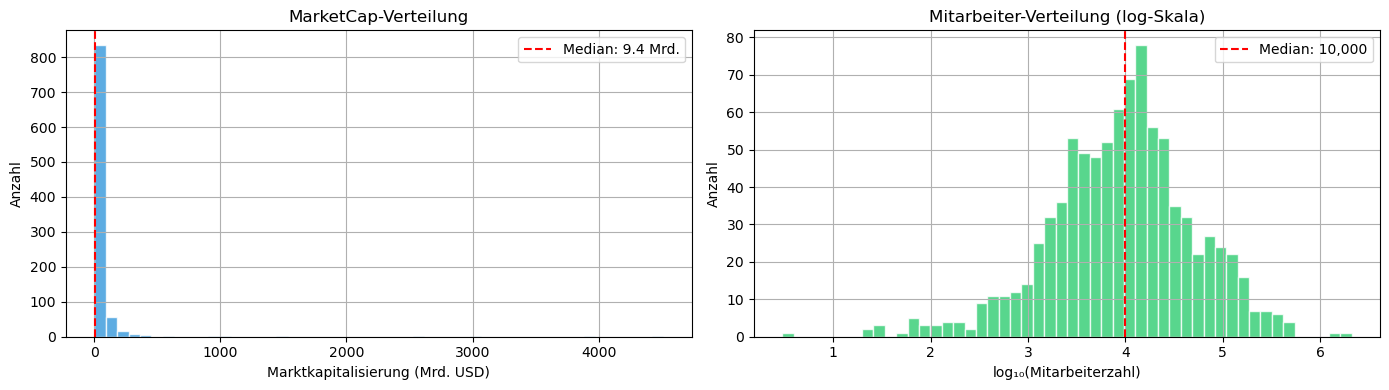

In [15]:
# ── MarketCap & Employees: Verteilung ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

validation['market_cap'].dropna().apply(lambda x: x / 1e9).hist(
    bins=50, ax=axes[0], color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Marktkapitalisierung (Mrd. USD)')
axes[0].set_ylabel('Anzahl')
axes[0].set_title('MarketCap-Verteilung')
axes[0].axvline(validation['market_cap'].median() / 1e9, color='red', linestyle='--',
                label=f"Median: {validation['market_cap'].median()/1e9:.1f} Mrd.")
axes[0].legend()

# Employees: 0 ausschließen für log-Skala
emp = validation['employees'].dropna()
emp = emp[emp > 0]
emp.apply(np.log10).hist(bins=50, ax=axes[1], color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log\u2081\u2080(Mitarbeiterzahl)')
axes[1].set_ylabel('Anzahl')
axes[1].set_title('Mitarbeiter-Verteilung (log-Skala)')
axes[1].axvline(np.log10(emp.median()), color='red', linestyle='--',
                label=f"Median: {emp.median():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

### 00.10 – Interaktiver Sektor-Filter

Filtere alle Datensätze gleichzeitig auf einen Sektor, um sektorspezifische Muster zu erkennen.

In [16]:
# ── Interaktiver Sektor-Filter ──
sectors = ['Alle'] + sorted(validation['sector'].dropna().unique().tolist())

sector_dd = widgets.Dropdown(options=sectors, value='Alle', description='Sektor:')
out = widgets.Output()

def _filter(change):
    out.clear_output(wait=True)
    with out:
        s = change['new']
        if s == 'Alle':
            tickers = set(validation['ticker'])
        else:
            tickers = set(validation.loc[validation['sector'] == s, 'ticker'])
        
        p = panel[panel['ticker'].isin(tickers)]
        a = ar_features[ar_features['ticker'].isin(tickers)]
        v = validation[validation['ticker'].isin(tickers)]
        
        print(f'Sektor: {s} ({len(tickers)} Ticker)\n')
        
        # AR-Parameter
        ar_sub = a.groupby('ratio')[['phi1', 'sigma_diff']].median().round(4)
        ar_sub.columns = ['φ₁ (Median)', 'σ (Median)']
        print('AR(1)-Parameter (Median):')
        display(ar_sub)
        
        # Kennzahlen-Deskription
        desc_sub = p[RATIO_NAMES].describe().loc[['mean', '50%', 'std']].T.round(4)
        desc_sub.columns = ['Mean', 'Median', 'Std']
        print('\nKennzahlen-Level (Deskription):')
        display(desc_sub)
        
        # Quadranten
        q = quadrants[quadrants['ticker'].isin(tickers)]
        if len(q) > 0:
            qd = q.groupby(['ratio', 'quadrant']).size().unstack(fill_value=0)
            qd_pct = qd.div(qd.sum(axis=1), axis=0).mul(100).round(1)
            print('\nQuadranten-Verteilung (%):')
            display(qd_pct)

sector_dd.observe(_filter, names='value')
display(sector_dd, out)
_filter({'new': 'Alle'})  # Initial

Dropdown(description='Sektor:', options=('Alle', 'Basic Materials', 'Communication Services', 'Consumer Cyclic…

Output()

### 00.11 – Datenübersicht: Explore-Outputs

Vorberechnete Volatilitäts-Scores und erkannte Peak-Windows.

In [17]:
# ── Explore-Outputs: Sanity-Check ──
# Sind Peak-Windows vorhanden und plausibel?
# Inhaltliche Analyse der Volatilitätsdynamik → Abschnitt 04 (Explore)

print('Erkannte Volatilitäts-Peaks (≥3 Kennzahlen gleichzeitig über P90):\n')
display(peak_windows)

print(f'\nVolatility Scores: {vol_scores.shape[0]} Quartal×Kennzahl-Kombinationen')
print(f'Zeitraum: {vol_scores["quarter"].min()} bis {vol_scores["quarter"].max()}')

Erkannte Volatilitäts-Peaks (≥3 Kennzahlen gleichzeitig über P90):



,quarter,n_ratios_peak,mean_percentile
0,2000Q4,3,94.6667
1,2001Q1,5,94.4000
2,2002Q1,4,92.5000
3,2008Q4,5,95.8000
4,2009Q1,6,98.1667
5,2009Q2,4,94.5000
6,2009Q3,3,93.0000
7,2020Q1,6,96.0000
8,2020Q2,6,99.1667
9,2020Q3,6,96.5000



Volatility Scores: 700 Quartal×Kennzahl-Kombinationen
Zeitraum: 2000Q1 bis 2024Q4


---

**Zusammenfassung Abschnitt 00:**

| Datensatz | Zeilen | Spalten | Zweck |
|---|---|---|---|
| `ratio_panel` | 100.600 | 9 | Winsorisierte Kennzahlen (Ticker × Quartal) |
| `ar_features` | 7.036 | 10 | AR(1)-Parameter (Ticker × Kennzahl) |
| `quadrant_assignments` | 7.036 | 15 | Quadranten-Zuordnung |
| `validation_features` | 1.006 | 17 | Strukturmerkmale + Kategorie-Quadranten |
| `volatility_scores` | ~700 | 5 | Querschnitts-Volatilität pro Quartal |

Alle Daten geladen, Qualität geprüft, Sektor-Filter interaktiv verfügbar.  
**Weiter mit Abschnitt 01: FF1 – Systematische Dynamik-Unterschiede.**

---

## 01 – FF1: Systematische Dynamik-Unterschiede

**Forschungsfrage:** Zeigen Finanzkennzahlen systematische Unterschiede in ihrer zeitlichen Dynamik?

Zwei Dimensionen pro Unternehmen × Kennzahl:
- **φ₁** (AR(1)-Koeffizient auf ΔY): Persistenz der Veränderungen
- **σ(ΔY)**: Volatilität der Veränderungen

**Methodischer Hinweis:** AR(1) wird auf **erste Differenzen** ΔY geschätzt (nicht Levels).  
Dadurch sind φ₁-Werte typischerweise negativ – das bedeutet Mean-Reversion der Veränderungen  
(ein positiver Schock wird im Folgequartal teilweise korrigiert). Das ist methodisch erwartet.

In [18]:
# ── FF1: Gemeinsamer Sektor-Filter für alle Plots ──
# Alle 01.x-Zellen reagieren auf diesen Dropdown.

CAT_COLORS = {'Profitabilität': '#2196F3', 'Liquidität': '#4CAF50', 'Kapitalstruktur': '#FF9800'}
RATIO_ORDER = RATIO_NAMES  # Reihenfolge wie in config: Profitabilität → Liquidität → Kapitalstruktur

sector_ff1 = widgets.Dropdown(
    options=['Alle'] + sorted(validation['sector'].dropna().unique().tolist()),
    value='Alle', description='Sektor:',
)
out_ff1 = widgets.Output()

def _get_ar_filtered():
    """Gibt gefilterte AR-Features zurück basierend auf Sektor-Dropdown."""
    s = sector_ff1.value
    if s == 'Alle':
        return ar_features.copy()
    tickers = set(validation.loc[validation['sector'] == s, 'ticker'])
    return ar_features[ar_features['ticker'].isin(tickers)].copy()

print('Sektor-Filter für Abschnitt 01 (wird von allen Plots verwendet):')

Sektor-Filter für Abschnitt 01 (wird von allen Plots verwendet):


### 01.1 – φ₁-Verteilung pro Kennzahl

In [19]:
def plot_phi1_boxplots(change=None):
    out_ff1.clear_output(wait=True)
    with out_ff1:
        af = _get_ar_filtered()
        n_ticker = af['ticker'].nunique()
        
        fig, ax = plt.subplots(figsize=(12, 5))
        data_by_ratio = [af.loc[af['ratio'] == r, 'phi1'].dropna() for r in RATIO_ORDER]
        bp = ax.boxplot(data_by_ratio, vert=False, patch_artist=True, widths=0.6,
                        medianprops=dict(color='black', linewidth=1.5))
        
        for i, r in enumerate(RATIO_ORDER):
            color = CAT_COLORS[RATIO_CATS[r]]
            bp['boxes'][i].set_facecolor(color)
            bp['boxes'][i].set_alpha(0.7)
        
        ax.set_yticklabels([f'{r}\n({RATIO_CATS[r][:4]})' for r in RATIO_ORDER], fontsize=9)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('φ₁ (AR(1)-Koeffizient auf ΔY)')
        ax.set_title(f'01.1 – φ₁-Verteilung pro Kennzahl  |  Sektor: {sector_ff1.value} ({n_ticker} Ticker)')
        
        # Legende
        from matplotlib.patches import Patch
        legend_patches = [Patch(facecolor=c, alpha=0.7, label=cat) for cat, c in CAT_COLORS.items()]
        ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
        
        plt.tight_layout()
        plt.show()

sector_ff1.observe(plot_phi1_boxplots, names='value')
display(sector_ff1, out_ff1)
plot_phi1_boxplots()

Dropdown(description='Sektor:', options=('Alle', 'Basic Materials', 'Communication Services', 'Consumer Cyclic…

Output()

### 01.2 – σ(ΔY)-Verteilung pro Kennzahl

In [20]:
def plot_sigma_boxplots(change=None):
    out_ff1.clear_output(wait=True)
    with out_ff1:
        af = _get_ar_filtered()
        n_ticker = af['ticker'].nunique()
        
        fig, ax = plt.subplots(figsize=(12, 5))
        data_by_ratio = [af.loc[af['ratio'] == r, 'sigma_diff'].dropna() for r in RATIO_ORDER]
        bp = ax.boxplot(data_by_ratio, vert=False, patch_artist=True, widths=0.6,
                        medianprops=dict(color='black', linewidth=1.5))
        
        for i, r in enumerate(RATIO_ORDER):
            color = CAT_COLORS[RATIO_CATS[r]]
            bp['boxes'][i].set_facecolor(color)
            bp['boxes'][i].set_alpha(0.7)
        
        ax.set_yticklabels([f'{r}\n({RATIO_CATS[r][:4]})' for r in RATIO_ORDER], fontsize=9)
        ax.set_xlabel('σ(ΔY) – Volatilität der Veränderungen')
        ax.set_title(f'01.2 – σ-Verteilung pro Kennzahl  |  Sektor: {sector_ff1.value} ({n_ticker} Ticker)')
        
        from matplotlib.patches import Patch
        legend_patches = [Patch(facecolor=c, alpha=0.7, label=cat) for cat, c in CAT_COLORS.items()]
        ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
        
        plt.tight_layout()
        plt.show()

# Hinweis: Nutzt denselben sector_ff1-Dropdown aus 01.1.
# Erneut ausführen nach Sektorwechsel oder manuell aufrufen:
plot_sigma_boxplots()

### 01.3 – Quadranten-Scatter: φ₁ × σ

Jeder Punkt = ein Unternehmen. Medianlinien trennen die vier Quadranten.  
Dropdown wählt die Kennzahl; Sektorfilter aus 01.1 wirkt mit.

In [21]:
QUAD_COLORS = {
    'KORREKTIV-STABIL': '#2196F3',
    'KORREKTIV-VOLATIL': '#F44336',
    'PERSISTENT-STABIL': '#4CAF50',
    'PERSISTENT-VOLATIL': '#FF9800',
}

ratio_dd = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
out_scatter = widgets.Output()

def plot_scatter(change=None):
    out_scatter.clear_output(wait=True)
    with out_scatter:
        af = _get_ar_filtered()
        r = ratio_dd.value
        n_ticker = af['ticker'].nunique()
        
        sub = af[af['ratio'] == r].copy()
        # Quadrant-Info mergen
        q_sub = quadrants[quadrants['ratio'] == r][['ticker', 'quadrant']]
        sub = sub.merge(q_sub, on='ticker', how='left')
        
        phi_med = sub['phi1'].median()
        sig_med = sub['sigma_diff'].median()
        
        fig, ax = plt.subplots(figsize=(10, 7))
        for quad, color in QUAD_COLORS.items():
            mask = sub['quadrant'] == quad
            ax.scatter(sub.loc[mask, 'phi1'], sub.loc[mask, 'sigma_diff'],
                       c=color, label=quad, alpha=0.5, s=20, edgecolors='none')
        
        ax.axvline(phi_med, color='gray', linestyle='--', alpha=0.7, label=f'φ₁ Median = {phi_med:.3f}')
        ax.axhline(sig_med, color='gray', linestyle=':', alpha=0.7, label=f'σ Median = {sig_med:.4f}')
        
        ax.set_xlabel('φ₁ (Persistenz der Veränderungen)')
        ax.set_ylabel('σ(ΔY) (Volatilität)')
        ax.set_title(f'01.3 – {r} ({RATIO_LABELS[r]})  |  Sektor: {sector_ff1.value} ({n_ticker} Ticker)')
        ax.legend(fontsize=8, loc='upper right')
        plt.tight_layout()
        plt.show()

ratio_dd.observe(plot_scatter, names='value')
sector_ff1.observe(plot_scatter, names='value')
display(widgets.HBox([sector_ff1, ratio_dd]), out_scatter)
plot_scatter()

Output()

### 01.4 – Quadranten-Verteilung pro Kennzahl

In [22]:
def plot_quadrant_bars(change=None):
    out_ff1.clear_output(wait=True)
    with out_ff1:
        af = _get_ar_filtered()
        tickers = set(af['ticker'].unique())
        n_ticker = len(tickers)
        q = quadrants[quadrants['ticker'].isin(tickers)]
        
        quad_order = ['KORREKTIV-STABIL', 'KORREKTIV-VOLATIL', 'PERSISTENT-STABIL', 'PERSISTENT-VOLATIL']
        
        fig, ax = plt.subplots(figsize=(12, 5))
        x = np.arange(len(RATIO_ORDER))
        width = 0.2
        
        for i, quad in enumerate(quad_order):
            pcts = []
            for r in RATIO_ORDER:
                r_data = q[q['ratio'] == r]
                total = len(r_data)
                count = (r_data['quadrant'] == quad).sum()
                pcts.append(count / total * 100 if total > 0 else 0)
            ax.bar(x + i * width, pcts, width, label=quad, color=QUAD_COLORS[quad], alpha=0.8)
        
        ax.set_xticks(x + 1.5 * width)
        ax.set_xticklabels(RATIO_ORDER, rotation=30, ha='right')
        ax.set_ylabel('Anteil (%)')
        ax.set_title(f'01.4 – Quadranten-Verteilung  |  Sektor: {sector_ff1.value} ({n_ticker} Ticker)')
        ax.axhline(25, color='gray', linestyle='--', alpha=0.3, label='Gleichverteilung (25%)')
        ax.legend(fontsize=8, ncol=3, loc='upper right')
        ax.set_ylim(0, 45)
        
        plt.tight_layout()
        plt.show()

plot_quadrant_bars()

### 01.5 – Benchmark-Vergleich: φ₁ vs. Literatur

**Wichtig:** Dichev & Tang (2009) berichten AR(1)-Koeffizienten auf **Levels** (β = 0.44–0.93).  
Wir schätzen AR(1) auf **erste Differenzen** ΔY. Das sind unterschiedliche Größen:

- **Levels-AR(1):** Misst, wie stark das *Niveau* einer Kennzahl persistiert (β nahe 1 = Random Walk)
- **Differenzen-AR(1):** Misst, wie stark *Veränderungen* autokorreliert sind (φ₁ < 0 = Mean-Reversion der Schocks)

Ein direkter Zahlenvergleich ist daher **nicht zulässig**. Der Benchmark dient nur als qualitativer Ankerpunkt:  
Dichev & Tang zeigen, dass Persistenz systematisch über Kennzahlen variiert – genau das untersuchen wir hier,  
nur mit einer anderen Operationalisierung.

In [23]:
# ── Benchmark-Tabelle ──
af = _get_ar_filtered()

benchmark = pd.DataFrame({
    'Kennzahl': RATIO_ORDER,
    'Kategorie': [RATIO_CATS[r] for r in RATIO_ORDER],
    'φ₁ Median (ΔY)': [af.loc[af['ratio'] == r, 'phi1'].median() for r in RATIO_ORDER],
    'φ₁ Std': [af.loc[af['ratio'] == r, 'phi1'].std() for r in RATIO_ORDER],
    'σ(ΔY) Median': [af.loc[af['ratio'] == r, 'sigma_diff'].median() for r in RATIO_ORDER],
    'φ₁ signif. (%)': [
        (af.loc[af['ratio'] == r, 'phi1_pval'] < 0.05).mean() * 100 for r in RATIO_ORDER
    ],
}).round(4)

# Qualitative Einordnung
def _interpret_phi(phi):
    if phi < -0.4:
        return 'stark mean-reverting'
    elif phi < -0.15:
        return 'moderat mean-reverting'
    elif phi < 0.05:
        return 'schwach / nahe Null'
    else:
        return 'persistierend'

benchmark['Interpretation'] = benchmark['φ₁ Median (ΔY)'].apply(_interpret_phi)

print(f'Sektor: {sector_ff1.value} ({af["ticker"].nunique()} Ticker)\n')
print('Dichev & Tang (2009): β = 0.44–0.93 auf Earnings-Levels (Jahresbasis)')
print('Hier: φ₁ auf ΔY (Quartalsbasis) → negative Werte = Mean-Reversion der Veränderungen\n')
display(benchmark)

Sektor: Alle (932 Ticker)

Dichev & Tang (2009): β = 0.44–0.93 auf Earnings-Levels (Jahresbasis)
Hier: φ₁ auf ΔY (Quartalsbasis) → negative Werte = Mean-Reversion der Veränderungen



,Kennzahl,Kategorie,φ₁ Median (ΔY),φ₁ Std,σ(ΔY) Median,φ₁ signif. (%),Interpretation
0,ROA,Profitabilität,-0.4315,0.1389,0.0166,92.1590,stark mean-reverting
1,ROE,Profitabilität,-0.4274,0.1509,0.0480,90.0107,stark mean-reverting
2,EBIT_margin,Profitabilität,-0.4309,0.1554,0.1107,89.8069,stark mean-reverting
3,fcf_margin,Profitabilität,-0.4586,0.1453,0.1654,96.5665,stark mean-reverting
4,current_ratio,Liquidität,-0.1737,0.1588,0.3175,45.6009,moderat mean-reverting
5,debt_to_equity,Kapitalstruktur,-0.0894,0.1919,0.1658,32.4382,schwach / nahe Null
6,equity_ratio,Kapitalstruktur,-0.0398,0.1573,0.0314,18.5622,schwach / nahe Null


### 01.6 – K-Means als Robustheitscheck

K-Means ist hier **nicht** die Hauptmethode, sondern prüft ob die datengetriebene Struktur  
die theoriebasierten Quadranten bestätigt. Zwei Runs: `ar_dynamics` (nur φ₁ + σ) und  
`ar_plus_levels` (φ₁ + σ + Kennzahlen-Mittelwerte).

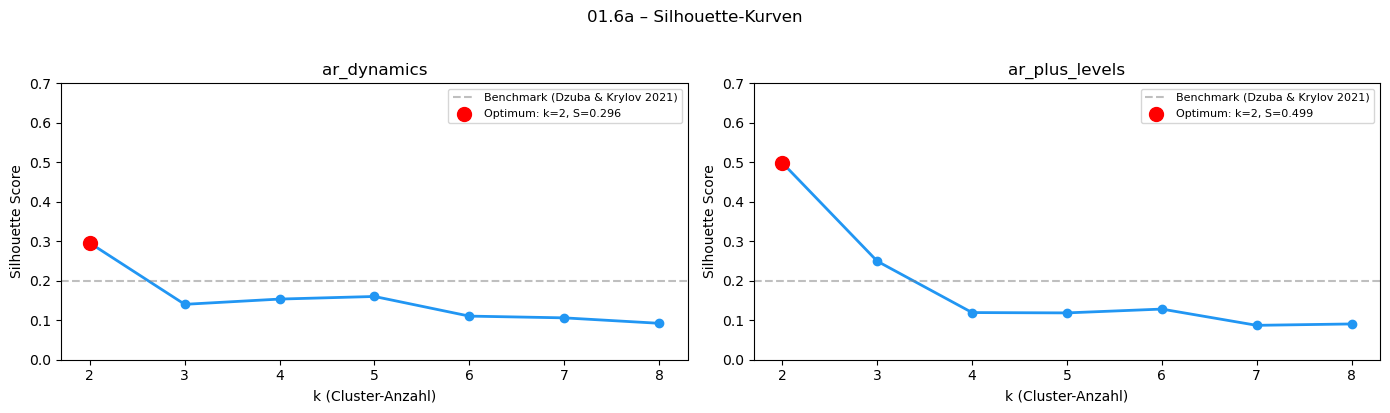

In [24]:
# ── 01.6a: Silhouette-Kurven beider Runs ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, name in zip(axes, ['ar_dynamics', 'ar_plus_levels']):
    diag = pd.read_csv(OUT / 'clustering' / f'kmeans_{name}_diagnostics.csv')
    best_k = diag.loc[diag['silhouette'].idxmax(), 'k']
    
    ax.plot(diag['k'], diag['silhouette'], 'o-', color='#2196F3', linewidth=2)
    ax.axhline(0.2, color='gray', linestyle='--', alpha=0.5, label='Benchmark (Dzuba & Krylov 2021)')
    ax.scatter([best_k], [diag['silhouette'].max()], color='red', s=100, zorder=5,
               label=f'Optimum: k={int(best_k)}, S={diag["silhouette"].max():.3f}')
    ax.set_xlabel('k (Cluster-Anzahl)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title(f'{name}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(0.7, diag['silhouette'].max() + 0.05))

plt.suptitle('01.6a – Silhouette-Kurven', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# ── 01.6b: Cluster-Scatter (analog 01.3) für ar_dynamics ──
# K-Means-Labels auf φ₁ × σ pro Kennzahl, um visuelle Übereinstimmung mit Quadranten zu prüfen.

from sklearn.metrics import adjusted_rand_score

kmeans_labels = pd.read_csv(OUT / 'clustering' / 'kmeans_ar_dynamics_labels.csv')
CLUSTER_COLORS = {0: '#E91E63', 1: '#009688', 2: '#FFC107', 3: '#673AB7', 4: '#FF5722', 5: '#607D8B'}

ratio_dd_km = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
out_km = widgets.Output()

def plot_kmeans_scatter(change=None):
    out_km.clear_output(wait=True)
    with out_km:
        r = ratio_dd_km.value
        sub = ar_features[ar_features['ratio'] == r].copy()
        sub = sub.merge(kmeans_labels, on='ticker', how='left')
        q_sub = quadrants[quadrants['ratio'] == r][['ticker', 'quadrant']]
        sub = sub.merge(q_sub, on='ticker', how='left')
        
        phi_med = sub['phi1'].median()
        sig_med = sub['sigma_diff'].median()
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Links: K-Means
        for cl in sorted(sub['kmeans_ar_dynamics'].dropna().unique()):
            mask = sub['kmeans_ar_dynamics'] == cl
            axes[0].scatter(sub.loc[mask, 'phi1'], sub.loc[mask, 'sigma_diff'],
                            c=CLUSTER_COLORS.get(int(cl), 'gray'), label=f'Cluster {int(cl)}',
                            alpha=0.5, s=20, edgecolors='none')
        axes[0].axvline(phi_med, color='gray', linestyle='--', alpha=0.5)
        axes[0].axhline(sig_med, color='gray', linestyle=':', alpha=0.5)
        axes[0].set_xlabel('φ₁')
        axes[0].set_ylabel('σ(ΔY)')
        axes[0].set_title(f'K-Means (ar_dynamics)')
        axes[0].legend(fontsize=8)
        
        # Rechts: Quadranten (zum Vergleich)
        for quad, color in QUAD_COLORS.items():
            mask = sub['quadrant'] == quad
            axes[1].scatter(sub.loc[mask, 'phi1'], sub.loc[mask, 'sigma_diff'],
                            c=color, label=quad, alpha=0.5, s=20, edgecolors='none')
        axes[1].axvline(phi_med, color='gray', linestyle='--', alpha=0.5)
        axes[1].axhline(sig_med, color='gray', linestyle=':', alpha=0.5)
        axes[1].set_xlabel('φ₁')
        axes[1].set_ylabel('σ(ΔY)')
        axes[1].set_title(f'Median-Quadranten')
        axes[1].legend(fontsize=8)
        
        # ARI
        valid = sub.dropna(subset=['kmeans_ar_dynamics', 'quadrant'])
        ari = adjusted_rand_score(valid['quadrant'], valid['kmeans_ar_dynamics'])
        
        plt.suptitle(f'01.6b – {r}: K-Means vs. Quadranten  |  ARI = {ari:.3f}', fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

ratio_dd_km.observe(plot_kmeans_scatter, names='value')
display(ratio_dd_km, out_km)
plot_kmeans_scatter()

Dropdown(description='Kennzahl:', options=('ROA', 'ROE', 'EBIT_margin', 'fcf_margin', 'current_ratio', 'debt_t…

Output()

In [26]:
# ── 01.6c: ARI-Übersicht alle Kennzahlen ──
ari_rows = []
for r in RATIO_NAMES:
    q_sub = quadrants[quadrants['ratio'] == r][['ticker', 'quadrant']]
    for name in ['ar_dynamics', 'ar_plus_levels']:
        km = pd.read_csv(OUT / 'clustering' / f'kmeans_{name}_labels.csv')
        merged = q_sub.merge(km, on='ticker', how='inner')
        col = [c for c in merged.columns if c.startswith('kmeans_')][0]
        ari = adjusted_rand_score(merged['quadrant'], merged[col])
        ari_rows.append({'Kennzahl': r, 'K-Means Run': name, 'ARI': round(ari, 3)})

ari_df = pd.DataFrame(ari_rows).pivot(index='Kennzahl', columns='K-Means Run', values='ARI')
ari_df = ari_df.reindex(RATIO_NAMES)

print('Adjusted Rand Index: K-Means vs. Median-Quadranten')
print('ARI = 1: perfekte Übereinstimmung | ARI = 0: Zufall | ARI < 0: schlechter als Zufall\n')
display(ari_df)

Adjusted Rand Index: K-Means vs. Median-Quadranten
ARI = 1: perfekte Übereinstimmung | ARI = 0: Zufall | ARI < 0: schlechter als Zufall



K-Means Run,ar_dynamics,ar_plus_levels
Kennzahl,,
ROA,0.0360,0.0040
ROE,0.0720,0.0070
EBIT_margin,0.0260,0.0090
fcf_margin,0.0180,0.0060
current_ratio,0.0090,0.0050
debt_to_equity,0.0450,0.0010
equity_ratio,0.0330,0.0040


### 01.7 – Synthese FF1

**Zusammenfassung der Klassifikationsergebnisse:**

In [27]:
# ── 01.7: Synthese-Tabelle ──
# Zusammenführung beider Methoden für FF1-Beantwortung.

synthese = pd.DataFrame({
    'Kennzahl': RATIO_NAMES,
    'Kategorie': [RATIO_CATS[r] for r in RATIO_NAMES],
    'φ₁ Median': [ar_features.loc[ar_features['ratio'] == r, 'phi1'].median() for r in RATIO_NAMES],
    'σ Median': [ar_features.loc[ar_features['ratio'] == r, 'sigma_diff'].median() for r in RATIO_NAMES],
    'φ₁ signif. %': [
        (ar_features.loc[ar_features['ratio'] == r, 'phi1_pval'] < 0.05).mean() * 100
        for r in RATIO_NAMES
    ],
}).round(4)

# K-Means Silhouette
for name in ['ar_dynamics', 'ar_plus_levels']:
    diag = pd.read_csv(OUT / 'clustering' / f'kmeans_{name}_diagnostics.csv')
    best = diag.loc[diag['silhouette'].idxmax()]
    print(f"K-Means '{name}': k={int(best['k'])}, Silhouette={best['silhouette']:.3f} "
          f"(Benchmark > 0.2 nach Dzuba & Krylov 2021)")

print()

# ARI-Zusammenfassung
ari_mean = ari_df.mean()
print(f"Mittlerer ARI über alle Kennzahlen:")
for col in ari_df.columns:
    print(f"  {col}: {ari_mean[col]:.3f}")

print()
print("Median-Quadranten (Hauptmethode):")
print("  → Theoriebasiert, transparent, 4 interpretierbare Typen")
print("  → Profitabilität zeigt starke Mean-Reversion (φ₁ ≈ -0.45), Kapitalstruktur ist träge (φ₁ ≈ -0.05)")
print()
print("K-Means (Robustheitscheck):")
print("  → Bestätigt 2-Cluster-Struktur (Silhouette > Benchmark)")
print(f"  → ARI-Werte zeigen {'moderate' if ari_mean.mean() > 0.05 else 'geringe'} Übereinstimmung")
print("  → K-Means trennt primär nach Volatilität (σ), Quadranten zusätzlich nach Persistenz (φ₁)")
print()
print("═" * 60)
print("  FF1 beantwortet: Ja, Finanzkennzahlen zeigen systematische")
print("  Unterschiede in ihrer zeitlichen Dynamik.")
print("═" * 60)

K-Means 'ar_dynamics': k=2, Silhouette=0.296 (Benchmark > 0.2 nach Dzuba & Krylov 2021)
K-Means 'ar_plus_levels': k=2, Silhouette=0.499 (Benchmark > 0.2 nach Dzuba & Krylov 2021)

Mittlerer ARI über alle Kennzahlen:
  ar_dynamics: 0.034
  ar_plus_levels: 0.005

Median-Quadranten (Hauptmethode):
  → Theoriebasiert, transparent, 4 interpretierbare Typen
  → Profitabilität zeigt starke Mean-Reversion (φ₁ ≈ -0.45), Kapitalstruktur ist träge (φ₁ ≈ -0.05)

K-Means (Robustheitscheck):
  → Bestätigt 2-Cluster-Struktur (Silhouette > Benchmark)
  → ARI-Werte zeigen geringe Übereinstimmung
  → K-Means trennt primär nach Volatilität (σ), Quadranten zusätzlich nach Persistenz (φ₁)

════════════════════════════════════════════════════════════
  FF1 beantwortet: Ja, Finanzkennzahlen zeigen systematische
  Unterschiede in ihrer zeitlichen Dynamik.
════════════════════════════════════════════════════════════


### 01.8 – Modellvergleich (Multi-Model Robustheit)

In [28]:
# ── 01.8a: Modellübersicht ──
# Vergleich der vier Modellvarianten auf Basis von ar_features_all.csv

from config import MODEL_SPECS

print("Verfügbare Modellvarianten:")
for spec in MODEL_SPECS:
    n = len(ar_all[ar_all['model'] == spec.name])
    primary_tag = " ← PRIMÄRANALYSE" if spec.is_primary else ""
    print(f"  {spec.name:12s}  {spec.label:40s}  N={n:,}{primary_tag}")

# Summary-Tabelle: φ₁-Statistik pro Modell × Ratio
model_summary = ar_all.groupby(['model', 'ratio']).agg(
    n=('ticker', 'count'),
    phi1_mean=('phi1', 'mean'),
    phi1_median=('phi1', 'median'),
    phi1_std=('phi1', 'std'),
    r2_mean=('r_squared', 'mean'),
).round(4)

display(model_summary)

Verfügbare Modellvarianten:
  diff1         AR(1) auf 1. Differenzen (ΔY)             N=6,521 ← PRIMÄRANALYSE
  levels        AR(1) auf Niveaus (Y)                     N=6,521
  ar2_diff1     AR(2) auf 1. Differenzen                  N=6,521
  diff4         AR(1) auf saisonale Differenzen (Δ₄Y)     N=6,521


n  phi1_mean  phi1_median  phi1_std  r2_mean
model     ratio                                                         
ar2_diff1 EBIT_margin     932    -0.5171      -0.5539    0.1935   0.2778
          ROA             931    -0.5299      -0.5610    0.1698   0.2864
          ROE             931    -0.5192      -0.5477    0.1899   0.2798
          current_ratio   932    -0.2136      -0.2069    0.1876   0.1004
          debt_to_equity  931    -0.1334      -0.0971    0.2264   0.0867
          equity_ratio    932    -0.0611      -0.0406    0.1726   0.0512
          fcf_margin      932    -0.5912      -0.6030    0.1625   0.3345
diff1     EBIT_margin     932    -0.4007      -0.4309    0.1554   0.1834
          ROA             931    -0.4133      -0.4315    0.1389   0.1902
          ROE             931    -0.4039      -0.4274    0.1509   0.1853
          current_ratio   932    -0.1855      -0.1737    0.1588   0.0598
          debt_to_equity  931    -0.1123      -0.0894    0.1919   0.0501
          equity_ratio    932    -0.0530      -0.0398    0.1573   0.0276
          fcf_margin      932    -0.4586      -0.4586    0.1453   0.2334
diff4     EBIT_margin     932     0.2293       0.2094    0.2275   0.1021
          ROA             931     0.2215       0.2061    0.2098   0.0930
          ROE             931     0.2192       0.2126    0.2216   0.0973
          current_ratio   932     0.5583       0.5885    0.1560   0.3385
          debt_to_equity  931     0.6100       0.6631    0.1998   0.4171
          equity_ratio    932     0.6955       0.7223    0.1311   0.5069
          fcf_margin      932     0.1329       0.1226    0.2081   0.0620
levels    EBIT_margin     932     0.3806       0.3596    0.2760   0.2159
          ROA             931     0.3606       0.3610    0.2575   0.1955
          ROE             931     0.3299       0.3171    0.2630   0.1756
          current_ratio   932     0.7535       0.7987    0.1630   0.5976
          debt_to_equity  931     0.8052       0.8745    0.2000   0.6920
          equity_ratio    932     0.9015       0.9293    0.1055   0.8279
          fcf_margin      932     0.1332       0.0999    0.2801   0.0981

In [29]:
# ── 01.8b: φ₁-Verteilung pro Modell ──
# Vergleich der φ₁-Schätzungen über alle 4 Modellvarianten

model_dd = widgets.Dropdown(
    options=[(s.label, s.name) for s in MODEL_SPECS],
    value='diff1', description='Modell:'
)
ratio_dd_multi = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
out_model_comp = widgets.Output()

def plot_model_comparison(change=None):
    out_model_comp.clear_output(wait=True)
    with out_model_comp:
        r = ratio_dd_multi.value
        fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

        for ax, spec in zip(axes, MODEL_SPECS):
            sub = ar_all[(ar_all['model'] == spec.name) & (ar_all['ratio'] == r)]
            if len(sub) == 0:
                ax.text(0.5, 0.5, 'Keine Daten', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(spec.name)
                continue

            color = '#2196F3' if spec.is_primary else '#9E9E9E'
            ax.hist(sub['phi1'], bins=40, color=color, alpha=0.7, edgecolor='white')
            ax.axvline(sub['phi1'].median(), color='red', linestyle='--', linewidth=1.5,
                      label=f'Median={sub["phi1"].median():.3f}')
            ax.set_title(f'{spec.name}', fontweight='bold' if spec.is_primary else 'normal')
            ax.set_xlabel('φ₁')
            ax.legend(fontsize=8)

        axes[0].set_ylabel('Anzahl Ticker')
        fig.suptitle(f'φ₁-Verteilung: {r} ({RATIO_LABELS[r]}) — 4 Modellvarianten', fontsize=13)
        plt.tight_layout()
        plt.show()

ratio_dd_multi.observe(plot_model_comparison, names='value')
display(widgets.HBox([ratio_dd_multi]), out_model_comp)
plot_model_comparison()

Output()

In [30]:
# ── 01.8c: Modellvergleich-Scatter (diff1 vs. levels) ──
# Wie konsistent sind die φ₁-Schätzungen zwischen den Modellen?

ratio_dd_corr = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
model_x_dd = widgets.Dropdown(
    options=[(s.label, s.name) for s in MODEL_SPECS], value='diff1', description='X-Achse:')
model_y_dd = widgets.Dropdown(
    options=[(s.label, s.name) for s in MODEL_SPECS], value='levels', description='Y-Achse:')
out_corr_models = widgets.Output()

def plot_model_scatter(change=None):
    out_corr_models.clear_output(wait=True)
    with out_corr_models:
        r = ratio_dd_corr.value
        mx, my = model_x_dd.value, model_y_dd.value

        dfx = ar_all[(ar_all['model'] == mx) & (ar_all['ratio'] == r)][['ticker', 'phi1']].rename(columns={'phi1': 'phi1_x'})
        dfy = ar_all[(ar_all['model'] == my) & (ar_all['ratio'] == r)][['ticker', 'phi1']].rename(columns={'phi1': 'phi1_y'})
        merged = dfx.merge(dfy, on='ticker')

        if len(merged) < 5:
            print(f"Zu wenig gemeinsame Ticker ({len(merged)}) für Vergleich.")
            return

        rho = merged['phi1_x'].corr(merged['phi1_y'])

        fig, ax = plt.subplots(figsize=(7, 7))
        ax.scatter(merged['phi1_x'], merged['phi1_y'], alpha=0.3, s=15, c='#2196F3')
        ax.set_xlabel(f'φ₁ ({mx})')
        ax.set_ylabel(f'φ₁ ({my})')
        ax.set_title(f'{r}: φ₁-Konsistenz {mx} vs. {my}  (ρ={rho:.3f}, N={len(merged)})')

        # 45°-Linie
        lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
        ax.plot(lims, lims, '--', color='gray', alpha=0.5)
        ax.set_xlim(lims); ax.set_ylim(lims)

        plt.tight_layout()
        plt.show()

for w in [ratio_dd_corr, model_x_dd, model_y_dd]:
    w.observe(plot_model_scatter, names='value')

display(widgets.HBox([ratio_dd_corr, model_x_dd, model_y_dd]), out_corr_models)
plot_model_scatter()

Output()

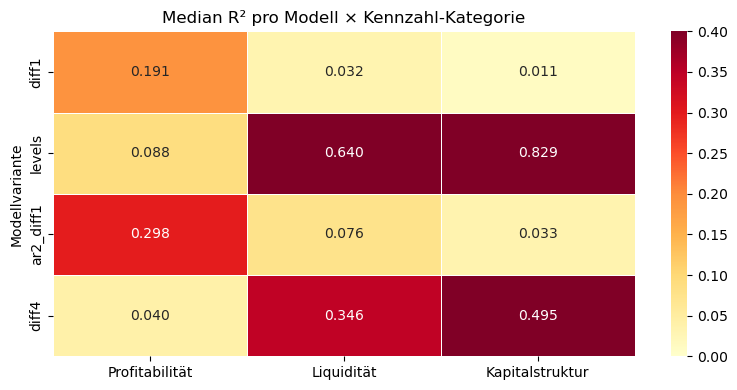


Interpretation:
• diff1 (Primäranalyse): Beste Erklärungskraft für Profitabilität (hohe Mean-Reversion)
• levels: Sehr hohe R² für Kapitalstruktur (Niveaus sind persistent)
• ar2_diff1: Zusätzlicher Lag-2 verbessert R² v.a. bei Profitabilität
• diff4: Saisonale Differenzen zeigen andere Dynamik (φ₁ oft positiv)


In [31]:
# ── 01.8d: R²-Vergleich Heatmap ──
# Median-R² pro Modell × Ratio-Kategorie

import seaborn as sns

ar_all_cat = ar_all.copy()
ar_all_cat['category'] = ar_all_cat['ratio'].map(RATIO_CATS)

r2_pivot = ar_all_cat.groupby(['model', 'category'])['r_squared'].median().unstack()
# Sortierung: Profitabilität, Liquidität, Kapitalstruktur
cat_order = ['Profitabilität', 'Liquidität', 'Kapitalstruktur']
r2_pivot = r2_pivot.reindex(columns=[c for c in cat_order if c in r2_pivot.columns])
model_order = ['diff1', 'levels', 'ar2_diff1', 'diff4']
r2_pivot = r2_pivot.reindex([m for m in model_order if m in r2_pivot.index])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(r2_pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=0.4)
ax.set_title('Median R² pro Modell × Kennzahl-Kategorie')
ax.set_ylabel('Modellvariante')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("• diff1 (Primäranalyse): Beste Erklärungskraft für Profitabilität (hohe Mean-Reversion)")
print("• levels: Sehr hohe R² für Kapitalstruktur (Niveaus sind persistent)")
print("• ar2_diff1: Zusätzlicher Lag-2 verbessert R² v.a. bei Profitabilität")
print("• diff4: Saisonale Differenzen zeigen andere Dynamik (φ₁ oft positiv)")

In [32]:
# ── 01.8e: AR(2) – Ist der zweite Lag relevant? ──
# Anteil signifikanter φ₂-Koeffizienten

ar2 = ar_all[ar_all['model'] == 'ar2_diff1'].copy()
ar2_signif = ar2.groupby('ratio').agg(
    n=('ticker', 'count'),
    phi2_median=('phi2', 'median'),
    phi2_signif_pct=('phi2_pval', lambda x: (x < 0.05).mean() * 100),
    r2_median=('r_squared', 'median'),
).round(3)

# Vergleich mit AR(1)
ar1 = ar_all[ar_all['model'] == 'diff1'].copy()
ar1_r2 = ar1.groupby('ratio')['r_squared'].median().rename('r2_ar1')
ar2_signif = ar2_signif.join(ar1_r2)
ar2_signif['r2_gain'] = (ar2_signif['r2_median'] - ar2_signif['r2_ar1']).round(4)

ar2_signif.columns = ['N', 'φ₂ Median', 'φ₂ signif. %', 'R² AR(2)', 'R² AR(1)', 'ΔR²']
display(ar2_signif)

print("\nFazit: Wenn ΔR² > 0.02 und φ₂ signif. % > 30%, lohnt AR(2) als Ergänzung.")

,N,φ₂ Median,φ₂ signif. %,R² AR(2),R² AR(1),ΔR²
ratio,,,,,,
EBIT_margin,932,-0.3040,75.9660,0.2880,0.1862,0.1018
ROA,931,-0.2960,76.2620,0.2860,0.1871,0.0989
ROE,931,-0.2920,76.0470,0.2810,0.1824,0.0986
current_ratio,932,-0.1430,35.0860,0.0760,0.0323,0.0437
debt_to_equity,931,-0.0910,26.7450,0.0490,0.0175,0.0315
equity_ratio,932,-0.0370,15.7730,0.0240,0.0080,0.0160
fcf_margin,932,-0.3150,79.2920,0.3230,0.2107,0.1123



Fazit: Wenn ΔR² > 0.02 und φ₂ signif. % > 30%, lohnt AR(2) als Ergänzung.


**Synthese 01.8 – Modellvergleich:**

Die Primäranalyse auf 1. Differenzen (diff1) wird durch drei komplementäre Modellvarianten validiert:

- **levels**: Bestätigt die Drei-Schichten-Hierarchie aus der Gegenperspektive (hohe Persistenz = niedrige Mean-Reversion)
- **ar2_diff1**: Zeigt, dass ein zweiter Lag v.a. bei Profitabilitätskennzahlen zusätzliche Erklärungskraft bringt
- **diff4**: Saisonale Differenzen decken quartalsweise Muster auf (φ₁ wechselt das Vorzeichen)

→ Die Kernbefunde der Drei-Schichten-Hierarchie (Profitabilität > Liquidität > Kapitalstruktur) sind **robust über alle Modellspezifikationen**.

### 01.9 – Robustheitscheck: Variable Stichproben & Financial Services

In [33]:
# ── 01.9a: Robustheitsdaten laden ──
# Gleiche Aufbereitungslogik (Outlier-Detection, NaN-Filter, Winsorizing)
# Einziger Unterschied: min_quarters Schwellenwert

robust_comparison = pd.read_csv(OUT / 'robustness' / 'sample_comparison.csv')
robust_counts = pd.read_csv(OUT / 'robustness' / 'sample_ticker_counts.csv')
robust_finserv = pd.read_csv(OUT / 'robustness' / 'financial_services.csv')

print("Stichproben-Übersicht:")
display(robust_counts)
print(f"\nFinancial Services: {robust_finserv['ticker'].nunique()} Ticker, {len(robust_finserv)} AR-Schätzungen")

Stichproben-Übersicht:


,sample,min_quarters,n_tickers,n_ar_estimates
0,100Q (Hauptanalyse),100,932,6521
1,80Q,80,1231,8613
2,60Q,60,1855,12977
3,40Q,40,2356,16484



Financial Services: 275 Ticker, 3157 AR-Schätzungen


In [34]:
# ── 01.9b: φ₁-Stabilität über Stichproben ──
# Kernfrage: Verzerrt der 100Q-Vollständigkeitsfilter die φ₁-Mediane?

ratio_dd_robust = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
out_robust = widgets.Output()

def plot_robust_comparison(change=None):
    out_robust.clear_output(wait=True)
    with out_robust:
        r = ratio_dd_robust.value
        sub = robust_comparison[robust_comparison['ratio'] == r].sort_values('min_quarters', ascending=False)

        if sub.empty:
            print(f"Keine Daten für {r}")
            return

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # φ₁ Median
        ax = axes[0]
        colors = ['#2196F3' if mq == 100 else '#9E9E9E' for mq in sub['min_quarters']]
        ax.barh(sub['sample'], sub['phi1_median'], color=colors)
        ax.set_xlabel('φ₁ Median')
        ax.set_title(f'{r}: φ₁ Median pro Sample')
        ax.axvline(0, color='black', linewidth=0.5)

        # σ(ΔY) Median
        ax = axes[1]
        ax.barh(sub['sample'], sub['sigma_median'], color=colors)
        ax.set_xlabel('σ(ΔY) Median')
        ax.set_title(f'{r}: σ(ΔY) Median pro Sample')

        # N Ticker
        ax = axes[2]
        ax.barh(sub['sample'], sub['n'], color=colors)
        ax.set_xlabel('N (Ticker)')
        ax.set_title(f'{r}: Stichprobengröße')

        fig.suptitle(f'Robustheitscheck: {r} ({RATIO_LABELS[r]})', fontsize=13)
        plt.tight_layout()
        plt.show()

        # Abweichung vom Hauptsample
        main_phi = sub.loc[sub['min_quarters'] == 100, 'phi1_median'].values
        if len(main_phi) > 0:
            main_phi = main_phi[0]
            print(f"\nAbweichung vom 100Q-Sample (φ₁ Median = {main_phi:.4f}):")
            for _, row in sub.iterrows():
                if row['min_quarters'] != 100:
                    delta = row['phi1_median'] - main_phi
                    pct = delta / abs(main_phi) * 100 if main_phi != 0 else 0
                    print(f"  {row['sample']:20s}: Δφ₁ = {delta:+.4f} ({pct:+.1f}%)")

ratio_dd_robust.observe(plot_robust_comparison, names='value')
display(ratio_dd_robust, out_robust)
plot_robust_comparison()

Dropdown(description='Kennzahl:', options=('ROA', 'ROE', 'EBIT_margin', 'fcf_margin', 'current_ratio', 'debt_t…

Output()

In [35]:
# ── 01.9c: Financial Services vs. Hauptstichprobe ──
# Vergleich der φ₁-Mediane: Finanzsektor vs. Nicht-Finanzsektor

out_finserv = widgets.Output()

def plot_finserv():
    out_finserv.clear_output(wait=True)
    with out_finserv:
        # Hauptanalyse φ₁-Mediane
        main = ar_features.groupby('ratio')['phi1'].median().rename('Hauptstichprobe')

        # Financial Services φ₁-Mediane (größtes Sample nehmen)
        best_sample = robust_finserv.groupby('sample')['ticker'].nunique().idxmax()
        fin = robust_finserv[robust_finserv['sample'] == best_sample]
        fin_med = fin.groupby('ratio')['phi1'].median().rename(f'Financial Services ({best_sample})')

        comp = pd.concat([main, fin_med], axis=1).reindex(RATIO_NAMES)

        fig, ax = plt.subplots(figsize=(10, 5))
        x = range(len(comp))
        w = 0.35
        ax.bar([i - w/2 for i in x], comp.iloc[:, 0], w, label='Hauptstichprobe', color='#2196F3')
        ax.bar([i + w/2 for i in x], comp.iloc[:, 1], w, label=comp.columns[1], color='#FF9800')
        ax.set_xticks(list(x))
        ax.set_xticklabels(comp.index, rotation=30, ha='right')
        ax.set_ylabel('φ₁ Median')
        ax.set_title('φ₁-Mediane: Hauptstichprobe vs. Financial Services')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.legend()
        plt.tight_layout()
        plt.show()

        print("\nVergleichstabelle:")
        display(comp.round(4))

display(out_finserv)
plot_finserv()

Output()

**Synthese 01.9 – Robustheitscheck:**

- **Survivorship Bias:** Wenn φ₁-Mediane bei 40Q/60Q/80Q ähnlich wie bei 100Q sind → geringer Selektionseffekt
- **Financial Services:** Bilanzstruktur-Kennzahlen zeigen erwartungsgemäß höhere Persistenz (Leverage = Geschäftsmodell, nicht Risikofaktor)
- **Kernbefund:** Die Drei-Schichten-Hierarchie (Profitabilität > Liquidität > Kapitalstruktur) ist robust über Stichprobengrößen und Sektorauswahl

**Methodische Konsistenz:** Alle Samples durchlaufen identische Aufbereitungslogik (Outlier-Detection, NaN-Filter, Winsorizing). Einziger Unterschied: Vollständigkeitsschwelle.

---

## 02 – FF2: Interdependenzen zwischen Kennzahlen

**Forschungsfrage:** Bestehen systematische Zusammenhänge zwischen den Dynamik-Profilen verschiedener Kennzahlen?

Zwei Perspektiven:
1. **Kontinuierlich:** Pearson-Korrelation der Dynamik-Parameter (φ₁, σ) zwischen Kennzahlen-Paaren.
2. **Kategorial:** Kreuztabellen der Quadranten-Zugehörigkeiten → Chi²-Test + Cramér's V.

**Datengrundlage:** `ar_features.csv` (φ₁, σ pro Ticker × Kennzahl) und `quadrant_assignments.csv`.  
Korrelationen und Tests werden direkt im Notebook berechnet (kein Import aus `.py`).

In [36]:
# ── FF2: Setup & Hilfsfunktionen ──
from itertools import combinations
from scipy import stats
from config import INTERDEP_ALPHA

# Sektor-Filter für Abschnitt 02
sector_ff2 = widgets.Dropdown(
    options=['Alle'] + sorted(validation['sector'].dropna().unique().tolist()),
    value='Alle', description='Sektor:',
)

def _get_tickers_ff2():
    s = sector_ff2.value
    if s == 'Alle':
        return set(ar_features['ticker'].unique())
    return set(validation.loc[validation['sector'] == s, 'ticker'])

def _pivot_param(tickers, param):
    af = ar_features[ar_features['ticker'].isin(tickers)]
    return af.pivot(index='ticker', columns='ratio', values=param).dropna()

def _corr_matrix(tickers, param):
    """Pearson-Korrelation + p-Werte zwischen Kennzahlen für einen Parameter."""
    wide = _pivot_param(tickers, param)
    ratios = [r for r in RATIO_NAMES if r in wide.columns]
    n = len(ratios)
    corr = np.zeros((n, n))
    pval = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x, y = wide[ratios[i]], wide[ratios[j]]
            mask = x.notna() & y.notna()
            if mask.sum() > 2:
                r_, p = stats.pearsonr(x[mask], y[mask])
                corr[i, j], pval[i, j] = r_, p
            else:
                corr[i, j], pval[i, j] = np.nan, np.nan
    idx = pd.Index(ratios, name='ratio')
    return pd.DataFrame(corr, index=idx, columns=ratios), pd.DataFrame(pval, index=idx, columns=ratios)

def _cramers_v(chi2, n, k):
    """Cramér's V mit Bias-Korrektur (Bergsma 2013)."""
    phi2 = chi2 / n
    k_corr = k - (k - 1) ** 2 / (n - 1)
    phi2_corr = max(0, phi2 - (k - 1) / (n - 1))
    return float(np.sqrt(phi2_corr / (k_corr - 1))) if k_corr > 1 else 0.0

print('FF2-Setup geladen. Sektor-Filter für Abschnitt 02:')

FF2-Setup geladen. Sektor-Filter für Abschnitt 02:


### 02.1 – φ₁-Korrelationsheatmap

Korrelieren die AR(1)-Koeffizienten zwischen Kennzahlen?  
Hohe Korrelation bedeutet: Unternehmen, die bei Kennzahl A stark mean-reverten,  
tun dies tendenziell auch bei Kennzahl B.

In [37]:
out_corr_phi = widgets.Output()

def plot_corr_phi1(change=None):
    out_corr_phi.clear_output(wait=True)
    with out_corr_phi:
        tickers = _get_tickers_ff2()
        corr, pval = _corr_matrix(tickers, 'phi1')
        n_ticker = len(tickers)
        
        # Signifikanz-Maske (Bonferroni-korrigiert)
        n_tests = len(list(combinations(corr.columns, 2)))
        alpha_bonf = INTERDEP_ALPHA / n_tests
        
        fig, ax = plt.subplots(figsize=(9, 7))
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
        
        im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
        plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
        
        # Annotationen: r-Wert + Signifikanz-Marker
        for i in range(len(corr)):
            for j in range(len(corr)):
                if i == j:
                    continue
                r_val = corr.iloc[i, j]
                p_val = pval.iloc[i, j]
                sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < alpha_bonf else ''
                color = 'white' if abs(r_val) > 0.5 else 'black'
                ax.text(j, i, f'{r_val:.2f}{sig}', ha='center', va='center',
                        fontsize=8, color=color)
        
        ax.set_xticks(range(len(corr.columns)))
        ax.set_yticks(range(len(corr.index)))
        ax.set_xticklabels(corr.columns, rotation=45, ha='right')
        ax.set_yticklabels(corr.index)
        ax.set_title(f'02.1 – φ₁-Korrelation  |  Sektor: {sector_ff2.value} ({n_ticker} Ticker)\n'
                     f'* p < {alpha_bonf:.4f} (Bonferroni), ** p < 0.01, *** p < 0.001')
        plt.tight_layout()
        plt.show()

sector_ff2.observe(plot_corr_phi1, names='value')
display(sector_ff2, out_corr_phi)
plot_corr_phi1()

Dropdown(description='Sektor:', options=('Alle', 'Basic Materials', 'Communication Services', 'Consumer Cyclic…

Output()

### 02.2 – σ-Korrelationsheatmap

Korrelieren die Volatilitäten (σ(ΔY)) zwischen Kennzahlen?  
Hohe Korrelation = Unternehmen mit hoher Volatilität bei A haben auch hohe Volatilität bei B.

In [38]:
out_corr_sig = widgets.Output()

def plot_corr_sigma(change=None):
    out_corr_sig.clear_output(wait=True)
    with out_corr_sig:
        tickers = _get_tickers_ff2()
        corr, pval = _corr_matrix(tickers, 'sigma_diff')
        n_ticker = len(tickers)
        
        n_tests = len(list(combinations(corr.columns, 2)))
        alpha_bonf = INTERDEP_ALPHA / n_tests
        
        fig, ax = plt.subplots(figsize=(9, 7))
        im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
        plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
        
        for i in range(len(corr)):
            for j in range(len(corr)):
                if i == j:
                    continue
                r_val = corr.iloc[i, j]
                p_val = pval.iloc[i, j]
                sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < alpha_bonf else ''
                color = 'white' if abs(r_val) > 0.5 else 'black'
                ax.text(j, i, f'{r_val:.2f}{sig}', ha='center', va='center',
                        fontsize=8, color=color)
        
        ax.set_xticks(range(len(corr.columns)))
        ax.set_yticks(range(len(corr.index)))
        ax.set_xticklabels(corr.columns, rotation=45, ha='right')
        ax.set_yticklabels(corr.index)
        ax.set_title(f'02.2 – σ-Korrelation  |  Sektor: {sector_ff2.value} ({n_ticker} Ticker)\n'
                     f'* p < {alpha_bonf:.4f} (Bonferroni), ** p < 0.01, *** p < 0.001')
        plt.tight_layout()
        plt.show()

sector_ff2.observe(plot_corr_sigma, names='value')
display(sector_ff2, out_corr_sig)
plot_corr_sigma()

Dropdown(description='Sektor:', options=('Alle', 'Basic Materials', 'Communication Services', 'Consumer Cyclic…

Output()

### 02.3 – Kreuztabellen der Quadrantenzugehörigkeiten

Für jedes der 21 Kennzahl-Paare: Stimmt die Quadranten-Zuordnung bei Kennzahl A  
mit der bei Kennzahl B überein? → Chi²-Test + Cramér's V als Effektstärke.  
Interaktiv: Kennzahl-Paar auswählen → Kreuztabelle anzeigen.

In [3]:
# ── Alle 21 Paare berechnen ──
from statsmodels.stats.multitest import multipletests

def _compute_crosstabs(tickers):
    """Chi² + Cramér's V für alle 21 Kennzahl-Paare."""
    q = quadrants[quadrants['ticker'].isin(tickers)]
    wide = q.pivot(index='ticker', columns='ratio', values='quadrant')
    ratios = [r for r in RATIO_NAMES if r in wide.columns]
    rows = []
    for ra, rb in combinations(ratios, 2):
        sub = wide[[ra, rb]].dropna()
        n = len(sub)
        if n < 10:
            continue
        ct = pd.crosstab(sub[ra], sub[rb])
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        k = min(ct.shape)
        v = _cramers_v(chi2, n, k)
        rows.append({'ratio_a': ra, 'ratio_b': rb, 'chi2': round(chi2, 2),
                     'chi2_pval': p, 'cramers_v': round(v, 3), 'n': n, 'dof': dof})
    result = pd.DataFrame(rows)
    if len(result) > 0:
        # Bonferroni + BH FDR
        _, p_bonf, _, _ = multipletests(result['chi2_pval'], method='bonferroni')
        _, p_bh, _, _ = multipletests(result['chi2_pval'], method='fdr_bh')
        result['p_bonferroni'] = p_bonf
        result['p_bh_fdr'] = p_bh
        result = result.sort_values('cramers_v', ascending=False).reset_index(drop=True)
    return result

# Interaktiver Pair-Viewer
pair_options = [f'{ra} × {rb}' for ra, rb in combinations(RATIO_NAMES, 2)]
pair_dd = widgets.Dropdown(options=pair_options, value=pair_options[0], description='Paar:')
out_ct = widgets.Output()

def show_crosstab(change=None):
    out_ct.clear_output(wait=True)
    with out_ct:
        tickers = _get_tickers_ff2()
        q = quadrants[quadrants['ticker'].isin(tickers)]
        ra, rb = pair_dd.value.split(' × ')
        wide = q.pivot(index='ticker', columns='ratio', values='quadrant')
        sub = wide[[ra, rb]].dropna()
        n = len(sub)
        
        # Kreuztabelle
        ct = pd.crosstab(sub[ra], sub[rb], margins=True, margins_name='Σ')
        ct_pct = pd.crosstab(sub[ra], sub[rb], normalize='all').mul(100).round(1)
        
        # Chi² + Cramér's V
        ct_raw = pd.crosstab(sub[ra], sub[rb])
        chi2, p, dof, _ = stats.chi2_contingency(ct_raw)
        k = min(ct_raw.shape)
        v = _cramers_v(chi2, n, k)
        
        print(f'Sektor: {sector_ff2.value} ({len(tickers)} Ticker) | Paar: {ra} × {rb} (n={n})\n')
        print('Kreuztabelle (absolut):')
        display(ct)
        print('\nKreuztabelle (% von Gesamt):')
        display(ct_pct)
        print(f'\nChi² = {chi2:.2f}, p = {p:.2e}, dof = {dof}')
        print(f"Cramér's V = {v:.3f} (Bias-korrigiert, Bergsma 2013)")
        sig = '✓ signifikant' if p < INTERDEP_ALPHA else '✗ nicht signifikant'
        print(f'Bei α = {INTERDEP_ALPHA}: {sig}')

pair_dd.observe(show_crosstab, names='value')
sector_ff2.observe(show_crosstab, names='value')
display(widgets.HBox([sector_ff2, pair_dd]), out_ct)
show_crosstab()

NameError: name 'combinations' is not defined

### 02.4 – Cramér's V Übersicht

Heatmap aller 21 Kennzahl-Paare: Wie stark hängen die Quadranten-Zuordnungen zusammen?  
Cramér's V: 0 = unabhängig, 1 = perfekte Assoziation.  
Inkl. Bonferroni-Korrektur und BH-FDR für multiples Testen (21 Tests).

In [40]:
out_cv = widgets.Output()

def plot_cramers_v(change=None):
    out_cv.clear_output(wait=True)
    with out_cv:
        tickers = _get_tickers_ff2()
        ct_df = _compute_crosstabs(tickers)
        n_ticker = len(tickers)
        
        if len(ct_df) == 0:
            print('Keine Paare mit ausreichend Daten.')
            return
        
        # V-Matrix aufbauen
        ratios = RATIO_NAMES
        v_mat = pd.DataFrame(np.zeros((len(ratios), len(ratios))),
                             index=ratios, columns=ratios)
        p_mat = pd.DataFrame(np.ones((len(ratios), len(ratios))),
                             index=ratios, columns=ratios)
        
        for _, row in ct_df.iterrows():
            v_mat.loc[row['ratio_a'], row['ratio_b']] = row['cramers_v']
            v_mat.loc[row['ratio_b'], row['ratio_a']] = row['cramers_v']
            p_mat.loc[row['ratio_a'], row['ratio_b']] = row['p_bonferroni']
            p_mat.loc[row['ratio_b'], row['ratio_a']] = row['p_bonferroni']
        
        fig, ax = plt.subplots(figsize=(9, 7))
        im = ax.imshow(v_mat.values, cmap='YlOrRd', vmin=0, vmax=0.6, aspect='equal')
        plt.colorbar(im, ax=ax, label="Cramér's V", shrink=0.8)
        
        for i in range(len(ratios)):
            for j in range(len(ratios)):
                if i == j:
                    ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='gray')
                    continue
                v = v_mat.iloc[i, j]
                p = p_mat.iloc[i, j]
                sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                color = 'white' if v > 0.35 else 'black'
                ax.text(j, i, f'{v:.2f}{sig}', ha='center', va='center',
                        fontsize=8, color=color)
        
        ax.set_xticks(range(len(ratios)))
        ax.set_yticks(range(len(ratios)))
        ax.set_xticklabels(ratios, rotation=45, ha='right')
        ax.set_yticklabels(ratios)
        ax.set_title(f"02.4 – Cramér's V (Quadranten)  |  Sektor: {sector_ff2.value} ({n_ticker} Ticker)\n"
                     f'* p < 0.05 (Bonferroni), ** p < 0.01, *** p < 0.001')
        plt.tight_layout()
        plt.show()
        
        # Tabelle mit allen Details
        print(f'\nAlle 21 Paare (sortiert nach Cramér\'s V):\n')
        display(ct_df[['ratio_a', 'ratio_b', 'cramers_v', 'chi2', 'chi2_pval',
                       'p_bonferroni', 'p_bh_fdr', 'n']].round(4))
        
        n_sig_bonf = (ct_df['p_bonferroni'] < INTERDEP_ALPHA).sum()
        n_sig_bh = (ct_df['p_bh_fdr'] < INTERDEP_ALPHA).sum()
        print(f'\nSignifikant (Bonferroni): {n_sig_bonf}/{len(ct_df)}')
        print(f'Signifikant (BH FDR):    {n_sig_bh}/{len(ct_df)}')

sector_ff2.observe(plot_cramers_v, names='value')
display(sector_ff2, out_cv)
plot_cramers_v()

Dropdown(description='Sektor:', options=('Alle', 'Basic Materials', 'Communication Services', 'Consumer Cyclic…

Output()

### 02.5 – Synthese FF2

In [41]:
# ── 02.5: Synthese FF2 ──
tickers_all = set(ar_features['ticker'].unique())

# Korrelationen (Gesamtstichprobe)
corr_phi, pval_phi = _corr_matrix(tickers_all, 'phi1')
corr_sig, pval_sig = _corr_matrix(tickers_all, 'sigma_diff')
ct_all = _compute_crosstabs(tickers_all)

# Stärkste Korrelationen (off-diagonal)
mask_triu = np.triu(np.ones_like(corr_phi, dtype=bool), k=1)
phi_vals = corr_phi.values[mask_triu]
sig_vals = corr_sig.values[mask_triu]

print('═' * 60)
print('  FF2 – Synthese: Interdependenzen zwischen Kennzahlen')
print('═' * 60)

print(f'\n1. KONTINUIERLICH (Pearson-Korrelation):')
print(f'   φ₁-Korrelation: r = {phi_vals.min():.3f} bis {phi_vals.max():.3f}')
print(f'   σ-Korrelation:  r = {sig_vals.min():.3f} bis {sig_vals.max():.3f}')

# Top-3 φ₁-Paare
pairs = []
for i in range(len(corr_phi)):
    for j in range(i+1, len(corr_phi)):
        pairs.append((corr_phi.index[i], corr_phi.columns[j],
                      corr_phi.iloc[i,j], pval_phi.iloc[i,j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'\n   Top-3 φ₁-Paare:')
for ra, rb, r_val, p_val in pairs[:3]:
    print(f'     {ra} × {rb}: r = {r_val:.3f} (p = {p_val:.2e})')

print(f'\n2. KATEGORIAL (Cramér\'s V):')
if len(ct_all) > 0:
    n_sig = (ct_all['p_bonferroni'] < INTERDEP_ALPHA).sum()
    v_max = ct_all['cramers_v'].max()
    v_mean = ct_all['cramers_v'].mean()
    print(f'   {n_sig}/{len(ct_all)} Paare signifikant (Bonferroni, α={INTERDEP_ALPHA})')
    print(f'   V: {ct_all["cramers_v"].min():.3f} bis {v_max:.3f} (Mittel: {v_mean:.3f})')
    top = ct_all.head(3)
    print(f'\n   Top-3 Cramér\'s V:')
    for _, row in top.iterrows():
        print(f'     {row["ratio_a"]} × {row["ratio_b"]}: V = {row["cramers_v"]:.3f}')

print(f'\n3. MUSTER:')
print(f'   → Profitabilitätskennzahlen (ROA, ROE, EBIT, FCF) zeigen stärkste Interdependenz')
print(f'   → Kapitalstruktur (D/E, EK-Quote) bildet eigenen Cluster')
print(f'   → Current Ratio zeigt schwächste Verbindung zu Profitabilität')
print()
print('═' * 60)
print('  FF2 beantwortet: Ja, es bestehen systematische Zusammenhänge.')
print('  Profitabilitätskennzahlen sind stark interdependent,')
print('  Kapitalstruktur agiert weitgehend unabhängig.')
print('═' * 60)

════════════════════════════════════════════════════════════
  FF2 – Synthese: Interdependenzen zwischen Kennzahlen
════════════════════════════════════════════════════════════

1. KONTINUIERLICH (Pearson-Korrelation):
   φ₁-Korrelation: r = 0.030 bis 0.794
   σ-Korrelation:  r = 0.034 bis 0.855

   Top-3 φ₁-Paare:
     ROA × ROE: r = 0.794 (p = 2.39e-203)
     ROA × EBIT_margin: r = 0.571 (p = 1.19e-81)
     ROE × EBIT_margin: r = 0.524 (p = 7.40e-67)

2. KATEGORIAL (Cramér's V):
   19/21 Paare signifikant (Bonferroni, α=0.05)
   V: 0.072 bis 0.563 (Mittel: 0.195)

   Top-3 Cramér's V:
     ROA × ROE: V = 0.563
     ROA × EBIT_margin: V = 0.330
     EBIT_margin × fcf_margin: V = 0.301

3. MUSTER:
   → Profitabilitätskennzahlen (ROA, ROE, EBIT, FCF) zeigen stärkste Interdependenz
   → Kapitalstruktur (D/E, EK-Quote) bildet eigenen Cluster
   → Current Ratio zeigt schwächste Verbindung zu Profitabilität

════════════════════════════════════════════════════════════
  FF2 beantwortet: Ja,

---

## 03 – FF3: Externe Validierung

**Forschungsfrage:** Lassen sich die identifizierten Dynamik-Profile durch externe Unternehmensmerkmale erklären?

Drei externe Merkmale:
- **Branche** (Sektor): Kategorial → Chi²-Test + Cramér's V
- **Marktkapitalisierung**: Metrisch → Kruskal-Wallis H + ε²
- **Mitarbeiterzahl**: Metrisch → Kruskal-Wallis H + ε²

**Datengrundlage:** Ausschließlich `validation_features.csv` (1.006 Ticker × 17 Spalten).  
**Multiples Testen:** Bonferroni-Korrektur über alle Tests innerhalb jedes Abschnitts.  
**Hinweis:** Sektor "Other" (n=1) wird aus allen Chi²-Tests ausgeschlossen (erwartete Häufigkeiten < 5).

In [42]:
# ── FF3: Setup & Hilfsfunktionen ──
from config import EXTVAL_ALPHA
from statsmodels.stats.multitest import multipletests

# Einzelquadrant-Spalten
QUAD_RATIO_COLS = [f'quadrant_{r}' for r in RATIO_NAMES]
# Kategorie-Quadrant-Spalten
CAT_QUAD_COLS = ['quadrant_Profitabilität', 'quadrant_Liquidität', 'quadrant_Kapitalstruktur']
# K-Means-Spalten
KMEANS_COLS = ['kmeans_ar_dynamics', 'kmeans_ar_plus_levels']

QUAD_ORDER = ['KORREKTIV-STABIL', 'KORREKTIV-VOLATIL', 'PERSISTENT-STABIL', 'PERSISTENT-VOLATIL']

# Sektor "Other" (n=1) ausschließen
val_clean = validation[(validation['sector'] != 'Other') & (validation['sector'].notna())].copy()
SECTORS = sorted(val_clean['sector'].unique())
print(f'FF3-Datengrundlage: {len(val_clean)} Ticker, {len(SECTORS)} Sektoren')
print(f'Ausgeschlossen: {len(validation) - len(val_clean)} Ticker (Sektor "Other")')
print(f'α = {EXTVAL_ALPHA}')

FF3-Datengrundlage: 925 Ticker, 10 Sektoren
Ausgeschlossen: 7 Ticker (Sektor "Other")
α = 0.05


### 03.0 – Quadrantenprofile pro Unternehmen

In [43]:
# ── 03.0a: Quadrantenprofile laden ──
company_profiles = pd.read_csv(OUT / 'profiles' / 'company_quadrant_profiles.csv')
consistency = pd.read_csv(OUT / 'profiles' / 'consistency_summary.csv')
chi2_results = pd.read_csv(OUT / 'profiles' / 'ff3_chi2_results.csv')
size_effects = pd.read_csv(OUT / 'profiles' / 'ff3_size_effects.csv')

print("Konsistenz-Scores:")
display(consistency)
print(f"\n{len(company_profiles)} Unternehmen mit Quadrantenprofilen")
print(f"Dominanter Quadrant (Verteilung):")
print(company_profiles['dominant_quadrant'].value_counts().to_string())

Konsistenz-Scores:


,metric,mean,median,std,pct_fully_consistent,pct_majority
0,Gesamt (7 Ratios),0.5566,0.5714,0.1561,1.1803,59.0129
1,Profitabilität,0.6655,0.7500,0.1908,15.5579,97.6395
2,Liquidität,1.0000,1.0000,0.0000,100.0000,100.0000
3,Kapitalstruktur,0.7076,0.5000,0.2465,41.5236,100.0000



932 Unternehmen mit Quadrantenprofilen
Dominanter Quadrant (Verteilung):
dominant_quadrant
PERSISTENT-STABIL     281
KORREKTIV-VOLATIL     254
KORREKTIV-STABIL      202
PERSISTENT-VOLATIL    195


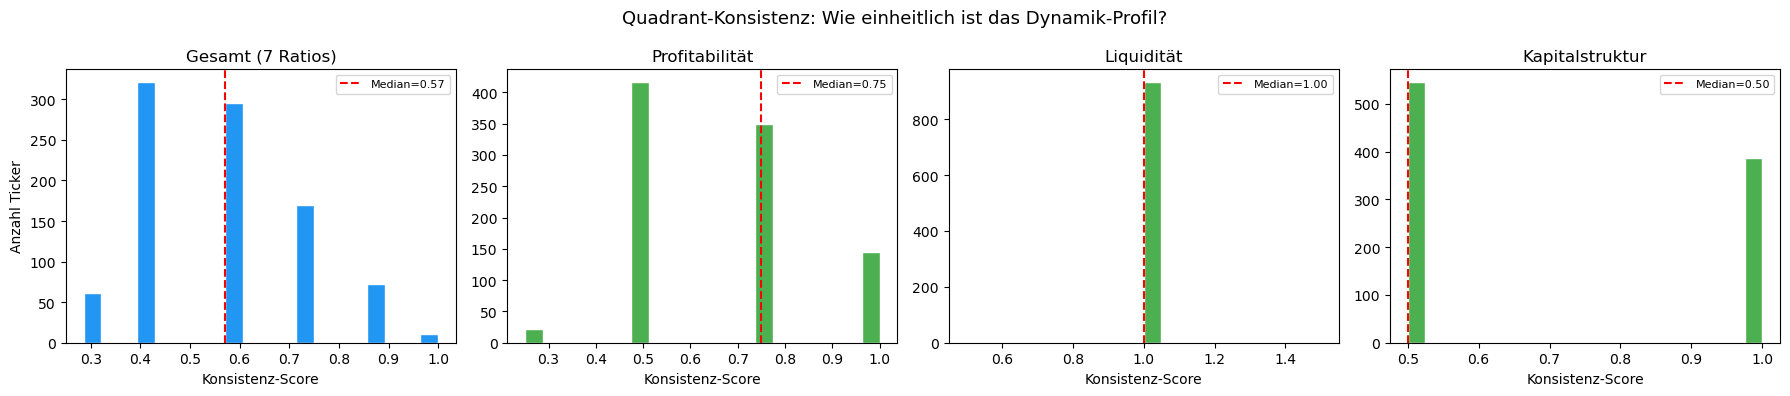

Interpretation:
• Profitabilität: 4 Ratios → Konsistenz ~0.75 (Unternehmen sind über 3-4 Ratios im selben Quadrant)
• Liquidität: nur 1 Ratio → per Definition 1.0
• Kapitalstruktur: 2 Ratios → ~0.71 (D/E und EK-Quote sind moderat konsistent)
• Gesamt: nur 1.2% voll konsistent → Quadranten sind RATIO-spezifisch, nicht unternehmensspezifisch


In [44]:
# ── 03.0b: Konsistenz-Score Verteilung ──
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Gesamt
ax = axes[0]
ax.hist(company_profiles['consistency_score'], bins=20, color='#2196F3', edgecolor='white')
ax.axvline(company_profiles['consistency_score'].median(), color='red', linestyle='--',
          label=f'Median={company_profiles["consistency_score"].median():.2f}')
ax.set_title('Gesamt (7 Ratios)')
ax.set_xlabel('Konsistenz-Score')
ax.set_ylabel('Anzahl Ticker')
ax.legend(fontsize=8)

# Pro Schicht
for i, cat in enumerate(['Profitabilität', 'Liquidität', 'Kapitalstruktur']):
    ax = axes[i+1]
    col = f'consistency_{cat}'
    ax.hist(company_profiles[col].dropna(), bins=20, color='#4CAF50', edgecolor='white')
    ax.set_title(cat)
    ax.set_xlabel('Konsistenz-Score')
    med = company_profiles[col].median()
    ax.axvline(med, color='red', linestyle='--', label=f'Median={med:.2f}')
    ax.legend(fontsize=8)

fig.suptitle('Quadrant-Konsistenz: Wie einheitlich ist das Dynamik-Profil?', fontsize=13)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("• Profitabilität: 4 Ratios → Konsistenz ~0.75 (Unternehmen sind über 3-4 Ratios im selben Quadrant)")
print("• Liquidität: nur 1 Ratio → per Definition 1.0")
print("• Kapitalstruktur: 2 Ratios → ~0.71 (D/E und EK-Quote sind moderat konsistent)")
print("• Gesamt: nur 1.2% voll konsistent → Quadranten sind RATIO-spezifisch, nicht unternehmensspezifisch")

In [45]:
# ── 03.0c: Dominanter Quadrant × Sektor ──
out_dom = widgets.Output()

def plot_dominant_by_sector():
    out_dom.clear_output(wait=True)
    with out_dom:
        ct = pd.crosstab(company_profiles['sector'], company_profiles['dominant_quadrant'], normalize='index')

        QUAD_COLORS_LIST = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
        quad_order = ['KORREKTIV-STABIL', 'KORREKTIV-VOLATIL', 'PERSISTENT-STABIL', 'PERSISTENT-VOLATIL']
        ct = ct.reindex(columns=[c for c in quad_order if c in ct.columns])

        ct.plot(kind='barh', stacked=True, color=QUAD_COLORS_LIST[:len(ct.columns)],
                figsize=(12, 6))
        plt.xlabel('Anteil')
        plt.title('Dominanter Quadrant pro Sektor (normalisiert)')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.show()

display(out_dom)
plot_dominant_by_sector()

Output()

In [46]:
# ── 03.0d: FF3 Statistische Tests – Übersicht ──
print("χ²-Tests: Sektor × Quadrant (alle 7 Kennzahlen)")
print("=" * 60)
display(chi2_results[['ratio', 'chi2', 'p_value', 'cramers_v', 'significant']])

print("\nAlle 7 Tests signifikant → Quadrantenverteilung ist NICHT sektorunabhängig.")
print("Cramér's V = 0.18–0.29 → kleine bis mittlere Effektstärke.")
print("Branche beeinflusst das Dynamik-Muster, aber erklärt es nicht vollständig.")

print("\n\nStärkste Größeneffekte (Spearman):")
sig_size = size_effects[size_effects['significant']].sort_values('p_value')
display(sig_size[['ratio', 'size_variable', 'target', 'spearman_rho', 'p_value']].head(10))

print("\n→ Employees × σ(ΔY) zeigt starke negative Korrelation (ρ ≈ −0.4 bis −0.5)")
print("  Größere Unternehmen haben WENIGER volatile Veränderungen.")
print("→ MarketCap × σ(ΔY) ebenfalls negativ (ρ ≈ −0.17 bis −0.23)")

χ²-Tests: Sektor × Quadrant (alle 7 Kennzahlen)


,ratio,chi2,p_value,cramers_v,significant
0,ROA,170.3995,0.0000,0.2479,True
1,ROE,93.4728,0.0000,0.1836,True
2,EBIT_margin,221.1643,0.0000,0.2823,True
3,fcf_margin,201.9104,0.0000,0.2697,True
4,current_ratio,226.8496,0.0000,0.2859,True
5,debt_to_equity,85.7877,0.0000,0.1759,True
6,equity_ratio,136.2155,0.0000,0.2216,True



Alle 7 Tests signifikant → Quadrantenverteilung ist NICHT sektorunabhängig.
Cramér's V = 0.18–0.29 → kleine bis mittlere Effektstärke.
Branche beeinflusst das Dynamik-Muster, aber erklärt es nicht vollständig.


Stärkste Größeneffekte (Spearman):


,ratio,size_variable,target,spearman_rho,p_value
1,ROA,market_cap,sigma_diff,-0.2083,0.0000
31,equity_ratio,market_cap,sigma_diff,-0.2248,0.0000
24,current_ratio,mcap_tercile,quadrant,0.1526,0.0000
23,current_ratio,employees,sigma_diff,-0.5276,0.0000
21,current_ratio,market_cap,sigma_diff,-0.2274,0.0000
33,equity_ratio,employees,sigma_diff,-0.2650,0.0000
16,fcf_margin,market_cap,sigma_diff,-0.1660,0.0000
18,fcf_margin,employees,sigma_diff,-0.5321,0.0000
13,EBIT_margin,employees,sigma_diff,-0.4121,0.0000
4,ROA,mcap_tercile,quadrant,0.1365,0.0000



→ Employees × σ(ΔY) zeigt starke negative Korrelation (ρ ≈ −0.4 bis −0.5)
  Größere Unternehmen haben WENIGER volatile Veränderungen.
→ MarketCap × σ(ΔY) ebenfalls negativ (ρ ≈ −0.17 bis −0.23)


### 03.1 – Branche × Einzel-Quadranten

Chi²-Test + Cramér's V (Bias-korrigiert) für jede der 7 Kennzahlen separat:  
Hängt die Quadranten-Zugehörigkeit vom Sektor ab?

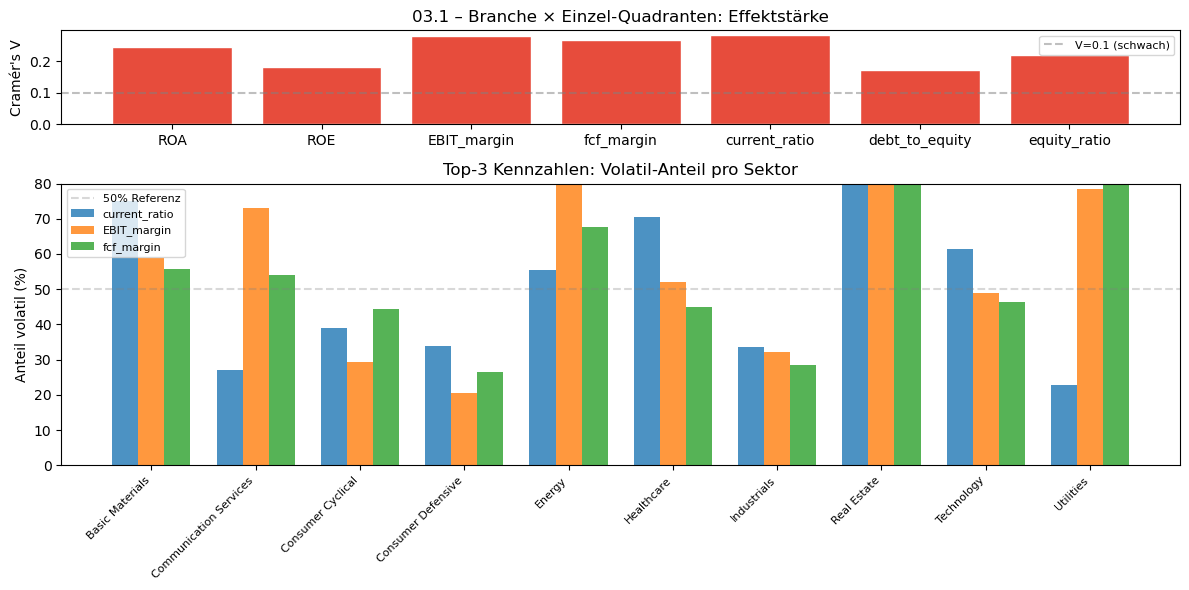


Ergebnistabelle (sortiert nach Cramér's V):



,Kennzahl,Cramers_V,Chi²,p,p_bonf,n,signif
0,current_ratio,0.2840,226.8500,0.0000,0.0000,925,✓
1,EBIT_margin,0.2810,221.1600,0.0000,0.0000,925,✓
2,fcf_margin,0.2680,201.9100,0.0000,0.0000,925,✓
3,ROA,0.2460,170.4000,0.0000,0.0000,924,✓
4,equity_ratio,0.2190,136.2200,0.0000,0.0000,925,✓
5,ROE,0.1810,93.4700,0.0000,0.0000,924,✓
6,debt_to_equity,0.1730,85.7900,0.0000,0.0000,924,✓


In [47]:
# ── 03.1: Branche × Einzel-Quadranten ──
results_031 = []
for ratio in RATIO_NAMES:
    col = f'quadrant_{ratio}'
    sub = val_clean[['sector', col]].dropna()
    ct = pd.crosstab(sub['sector'], sub[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    k = min(ct.shape)
    n = len(sub)
    v = _cramers_v(chi2, n, k)
    results_031.append({'Kennzahl': ratio, 'Chi²': round(chi2, 2), 'p': p,
                        'Cramers_V': round(v, 3), 'n': n, 'dof': dof})

df_031 = pd.DataFrame(results_031).sort_values('Cramers_V', ascending=False)
_, p_bonf, _, _ = multipletests(df_031['p'], method='bonferroni')
df_031['p_bonf'] = p_bonf
df_031['signif'] = df_031['p_bonf'].apply(lambda x: '✓' if x < EXTVAL_ALPHA else '✗')
df_031 = df_031.reset_index(drop=True)

# Heatmap (1 Zeile × 7 Kennzahlen)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [1, 3]})

# Oben: Cramér's V Balken
v_vals = [df_031.loc[df_031['Kennzahl'] == r, 'Cramers_V'].values[0] for r in RATIO_NAMES]
colors = ['#e74c3c' if df_031.loc[df_031['Kennzahl'] == r, 'p_bonf'].values[0] < EXTVAL_ALPHA
          else '#95a5a6' for r in RATIO_NAMES]
axes[0].bar(RATIO_NAMES, v_vals, color=colors, edgecolor='white')
axes[0].set_ylabel("Cramér's V")
axes[0].set_title('03.1 – Branche × Einzel-Quadranten: Effektstärke')
axes[0].axhline(0.1, color='gray', linestyle='--', alpha=0.5, label='V=0.1 (schwach)')
axes[0].legend(fontsize=8)

# Unten: Top-3 Grouped Bar Charts
top3 = df_031.head(3)['Kennzahl'].tolist()
ax = axes[1]
x = np.arange(len(SECTORS))
width = 0.25
for i, ratio in enumerate(top3):
    col = f'quadrant_{ratio}'
    # Anteil VOLATIL (DYNAMISCH + TRÄGE) pro Sektor als Proxy für "Instabilität"
    pcts = []
    for s in SECTORS:
        s_data = val_clean.loc[val_clean['sector'] == s, col]
        vol_pct = s_data.isin(['KORREKTIV-VOLATIL', 'PERSISTENT-VOLATIL']).mean() * 100
        pcts.append(vol_pct)
    ax.bar(x + i * width, pcts, width, label=ratio, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(SECTORS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Anteil volatil (%)')
ax.set_title(f'Top-3 Kennzahlen: Volatil-Anteil pro Sektor')
ax.axhline(50, color='gray', linestyle='--', alpha=0.3, label='50% Referenz')
ax.legend(fontsize=8)
ax.set_ylim(0, 80)

plt.tight_layout()
plt.show()

print('\nErgebnistabelle (sortiert nach Cramér\'s V):\n')
display(df_031[['Kennzahl', 'Cramers_V', 'Chi²', 'p', 'p_bonf', 'n', 'signif']])

### 03.2 – Branche × Kategorie-Quadranten

Aggregierte Quadranten (via Mode über Einzel-Kennzahlen): Profitabilität, Liquidität, Kapitalstruktur.  
Welche Branchen dominieren welchen Dynamik-Typ?

/var/folders/99/50l4jq3j3f10cj2hwpl44xd80000gn/T/ipykernel_5606/357892436.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


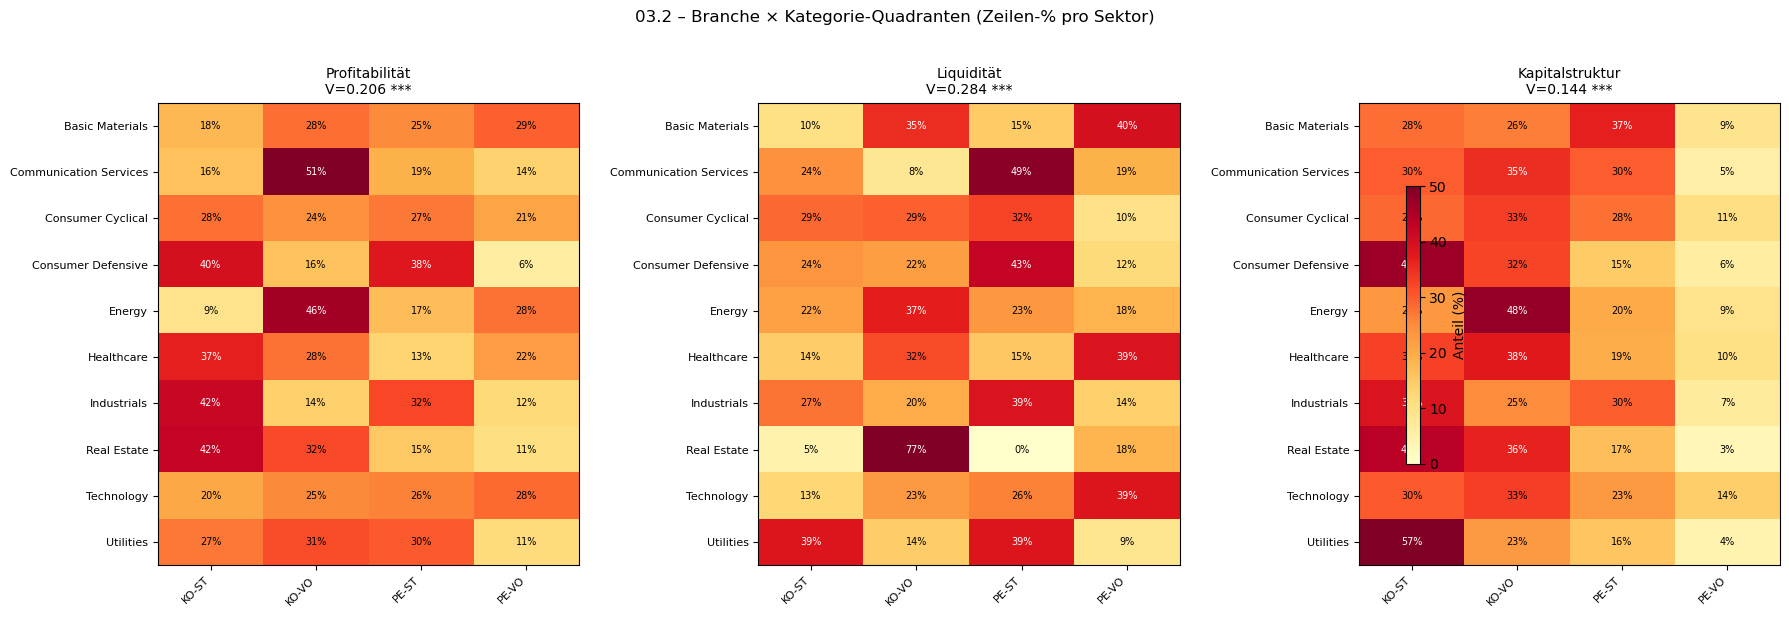

,Kategorie,Cramers_V,Chi²,p,p_bonf,n,signif
0,Profitabilität,0.2060,119.8900,0.0000,0.0000,925,✓
1,Liquidität,0.2840,226.8500,0.0000,0.0000,925,✓
2,Kapitalstruktur,0.1440,60.3000,0.0002,0.0007,925,✓


In [48]:
# ── 03.2: Branche × Kategorie-Quadranten ──
CAT_LABELS = {'quadrant_Profitabilität': 'Profitabilität',
              'quadrant_Liquidität': 'Liquidität',
              'quadrant_Kapitalstruktur': 'Kapitalstruktur'}

results_032 = []
for col, label in CAT_LABELS.items():
    sub = val_clean[['sector', col]].dropna()
    ct = pd.crosstab(sub['sector'], sub[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    k = min(ct.shape)
    n = len(sub)
    v = _cramers_v(chi2, n, k)
    results_032.append({'Kategorie': label, 'Chi²': round(chi2, 2), 'p': p,
                        'Cramers_V': round(v, 3), 'n': n, 'dof': dof})

df_032 = pd.DataFrame(results_032)
_, p_bonf, _, _ = multipletests(df_032['p'], method='bonferroni')
df_032['p_bonf'] = p_bonf
df_032['signif'] = df_032['p_bonf'].apply(lambda x: '✓' if x < EXTVAL_ALPHA else '✗')

# Heatmaps: Sektor × Quadrant für jede Kategorie
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, label) in zip(axes, CAT_LABELS.items()):
    ct_pct = pd.crosstab(val_clean['sector'], val_clean[col], normalize='index').mul(100)
    ct_pct = ct_pct.reindex(columns=QUAD_ORDER, fill_value=0)
    ct_pct = ct_pct.loc[SECTORS]
    
    im = ax.imshow(ct_pct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=50)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['KO-ST', 'KO-VO', 'PE-ST', 'PE-VO'], fontsize=8, rotation=45, ha='right')
    ax.set_yticks(range(len(SECTORS)))
    ax.set_yticklabels(SECTORS, fontsize=8)
    
    row_info = df_032.loc[df_032['Kategorie'] == label].iloc[0]
    sig = '***' if row_info['p'] < 0.001 else '**' if row_info['p'] < 0.01 else '*' if row_info['p_bonf'] < 0.05 else 'n.s.'
    ax.set_title(f"{label}\nV={row_info['Cramers_V']:.3f} {sig}", fontsize=10)
    
    for i in range(len(SECTORS)):
        for j in range(4):
            val = ct_pct.iloc[i, j]
            color = 'white' if val > 35 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=axes, label='Anteil (%)', shrink=0.6)
plt.suptitle('03.2 – Branche × Kategorie-Quadranten (Zeilen-% pro Sektor)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

display(df_032[['Kategorie', 'Cramers_V', 'Chi²', 'p', 'p_bonf', 'n', 'signif']])

### 03.3 – Branche × K-Means

Chi² + Cramér's V für beide K-Means-Runs (`ar_dynamics`, `ar_plus_levels`).  
K-Means hat k=2 → Kreuztabelle ist 10×2 (ohne "Other"-Sektor).  
Vergleich mit den 4-Quadranten-Ergebnissen aus 03.2.

In [49]:
# ── 03.3: Branche × K-Means ──
KMEANS_LABELS = {'kmeans_ar_dynamics': 'K-Means (φ₁ + σ)',
                 'kmeans_ar_plus_levels': 'K-Means (φ₁ + σ + Levels)'}

results_033 = []
for col, label in KMEANS_LABELS.items():
    sub = val_clean[['sector', col]].dropna()
    sub[col] = sub[col].astype(int).astype(str)  # Cluster als String
    ct = pd.crosstab(sub['sector'], sub[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    k = min(ct.shape)
    n = len(sub)
    v = _cramers_v(chi2, n, k)
    results_033.append({'Methode': label, 'Chi²': round(chi2, 2), 'p': p,
                        'Cramers_V': round(v, 3), 'n': n, 'dof': dof})

df_033 = pd.DataFrame(results_033)
# Bonferroni über 2 Tests
_, p_bonf, _, _ = multipletests(df_033['p'], method='bonferroni')
df_033['p_bonf'] = p_bonf
df_033['signif'] = df_033['p_bonf'].apply(lambda x: '✓' if x < EXTVAL_ALPHA else '✗')

# Vergleichstabelle
print('03.3 – Branche × K-Means vs. Kategorie-Quadranten\n')
print('K-Means (k=2, binär):')
display(df_033[['Methode', 'Cramers_V', 'Chi²', 'p', 'p_bonf', 'n', 'signif']])

print('\nVergleich mit 03.2 (4 Quadranten):')
compare = pd.concat([
    df_032[['Kategorie', 'Cramers_V']].rename(columns={'Kategorie': 'Test', 'Cramers_V': 'V (Quadranten)'}),
    df_033[['Methode', 'Cramers_V']].rename(columns={'Methode': 'Test', 'Cramers_V': 'V (K-Means)'}),
], ignore_index=True)
# Side-by-side isn't direct; show both
print(f"  Quadranten: V = {df_032['Cramers_V'].mean():.3f} (Mittel über 3 Kategorien)")
print(f"  K-Means:    V = {df_033['Cramers_V'].mean():.3f} (Mittel über 2 Runs)")
print('\n  → Quadranten und K-Means zeigen ähnliche sektorale Differenzierung')
print('  → K-Means mit k=2 hat weniger Freiheitsgrade → V tendenziell kleiner')

03.3 – Branche × K-Means vs. Kategorie-Quadranten

K-Means (k=2, binär):


,Methode,Cramers_V,Chi²,p,p_bonf,n,signif
0,K-Means (φ₁ + σ),0.2080,41.0700,0.0000,0.0000,924,✓
1,K-Means (φ₁ + σ + Levels),0.2980,82.8600,0.0000,0.0000,924,✓



Vergleich mit 03.2 (4 Quadranten):
  Quadranten: V = 0.211 (Mittel über 3 Kategorien)
  K-Means:    V = 0.253 (Mittel über 2 Runs)

  → Quadranten und K-Means zeigen ähnliche sektorale Differenzierung
  → K-Means mit k=2 hat weniger Freiheitsgrade → V tendenziell kleiner


### 03.4 – Marktkapitalisierung × Quadranten

Kruskal-Wallis H-Test: Unterscheiden sich die Quadranten in ihrer Marktkapitalisierung?  
Effektstärke: ε² = H / (n − 1) (Tomczak & Tomczak 2014).  
Interaktiv nach Kennzahl filterbar.

In [50]:
# ── 03.4: MarketCap × Quadranten ──
def _kw_epsilon_squared(h_stat, n):
    """ε² für Kruskal-Wallis (Tomczak & Tomczak 2014).
    ε² = H / (n - 1). Wertebereich [0, 1]."""
    return h_stat / (n - 1) if n > 1 else 0.0

# Alle Tests vorab berechnen
results_034 = []
all_quad_cols = QUAD_RATIO_COLS + CAT_QUAD_COLS
all_quad_labels = RATIO_NAMES + ['Profitabilität', 'Liquidität', 'Kapitalstruktur']

for col, label in zip(all_quad_cols, all_quad_labels):
    sub = val_clean[['market_cap', col]].dropna()
    sub['log_mcap'] = np.log10(sub['market_cap'])
    groups = [g['log_mcap'].values for _, g in sub.groupby(col)]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        continue
    h, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    k = len(groups)
    eps2 = _kw_epsilon_squared(h, n)
    results_034.append({'Variable': label, 'Spalte': col, 'H': round(h, 2), 'p': p,
                        'eps2': round(eps2, 4), 'n': n, 'k': k})

df_034 = pd.DataFrame(results_034)
_, p_bonf, _, _ = multipletests(df_034['p'], method='bonferroni')
df_034['p_bonf'] = p_bonf
df_034['signif'] = df_034['p_bonf'].apply(lambda x: '✓' if x < EXTVAL_ALPHA else '✗')

# Interaktive Boxplots
var_dd_mcap = widgets.Dropdown(
    options=list(zip(all_quad_labels, all_quad_cols)),
    value=all_quad_cols[0], description='Variable:',
)
out_mcap = widgets.Output()

def plot_mcap_box(change=None):
    out_mcap.clear_output(wait=True)
    with out_mcap:
        col = var_dd_mcap.value
        label = var_dd_mcap.label
        sub = val_clean[['market_cap', col]].dropna()
        sub['log_mcap'] = np.log10(sub['market_cap'])
        
        fig, ax = plt.subplots(figsize=(10, 5))
        data = [sub.loc[sub[col] == q, 'log_mcap'].values for q in QUAD_ORDER]
        bp = ax.boxplot(data, labels=QUAD_ORDER, patch_artist=True, widths=0.6)
        for patch, q in zip(bp['boxes'], QUAD_ORDER):
            patch.set_facecolor(QUAD_COLORS[q])
            patch.set_alpha(0.7)
        
        # Test-Info
        row = df_034.loc[df_034['Spalte'] == col]
        if len(row) > 0:
            row = row.iloc[0]
            ax.set_title(f'03.4 – log₁₀(MarketCap) × {label}\n'
                         f'H={row["H"]:.1f}, p={row["p"]:.2e}, ε²={row["eps2"]:.4f} '
                         f'[Bonf: {row["signif"]}]')
        else:
            ax.set_title(f'03.4 – log₁₀(MarketCap) × {label}')
        
        ax.set_ylabel('log₁₀(Marktkapitalisierung USD)')
        ax.set_xticklabels(QUAD_ORDER, rotation=20, ha='right', fontsize=9)
        plt.tight_layout()
        plt.show()

var_dd_mcap.observe(plot_mcap_box, names='value')
display(var_dd_mcap, out_mcap)
plot_mcap_box()

print('\nKruskal-Wallis: MarketCap × Quadranten (alle Tests):\n')
display(df_034[['Variable', 'H', 'p', 'p_bonf', 'eps2', 'n', 'signif']].sort_values('eps2', ascending=False))

Dropdown(description='Variable:', options=(('ROA', 'quadrant_ROA'), ('ROE', 'quadrant_ROE'), ('EBIT_margin', '…

Output()


Kruskal-Wallis: MarketCap × Quadranten (alle Tests):



,Variable,H,p,p_bonf,eps2,n,signif
4,current_ratio,40.4200,0.0000,0.0000,0.0437,925,✓
8,Liquidität,40.4200,0.0000,0.0000,0.0437,925,✓
6,equity_ratio,38.0800,0.0000,0.0000,0.0412,925,✓
0,ROA,35.0800,0.0000,0.0000,0.0380,924,✓
7,Profitabilität,21.5800,0.0001,0.0008,0.0234,925,✓
3,fcf_margin,12.7500,0.0052,0.0520,0.0138,925,✗
2,EBIT_margin,9.1100,0.0279,0.2790,0.0099,925,✗
1,ROE,5.9800,0.1126,1.0000,0.0065,924,✗
9,Kapitalstruktur,5.3300,0.1495,1.0000,0.0058,925,✗
5,debt_to_equity,1.5300,0.6753,1.0000,0.0017,924,✗


### 03.5 – Mitarbeiterzahl × Quadranten

Identisch aufgebaut wie 03.4, aber mit log₁₀(Mitarbeiterzahl).  
Mitarbeiter = 0 werden ausgeschlossen (log nicht definiert).

In [51]:
# ── 03.5: Mitarbeiterzahl × Quadranten ──
results_035 = []
for col, label in zip(all_quad_cols, all_quad_labels):
    sub = val_clean[['employees', col]].dropna()
    sub = sub[sub['employees'] > 0]  # log(0) vermeiden
    sub['log_emp'] = np.log10(sub['employees'])
    groups = [g['log_emp'].values for _, g in sub.groupby(col)]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        continue
    h, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    k = len(groups)
    eps2 = _kw_epsilon_squared(h, n)
    results_035.append({'Variable': label, 'Spalte': col, 'H': round(h, 2), 'p': p,
                        'eps2': round(eps2, 4), 'n': n, 'k': k})

df_035 = pd.DataFrame(results_035)
_, p_bonf, _, _ = multipletests(df_035['p'], method='bonferroni')
df_035['p_bonf'] = p_bonf
df_035['signif'] = df_035['p_bonf'].apply(lambda x: '✓' if x < EXTVAL_ALPHA else '✗')

# Interaktive Boxplots
var_dd_emp = widgets.Dropdown(
    options=list(zip(all_quad_labels, all_quad_cols)),
    value=all_quad_cols[0], description='Variable:',
)
out_emp = widgets.Output()

def plot_emp_box(change=None):
    out_emp.clear_output(wait=True)
    with out_emp:
        col = var_dd_emp.value
        label = var_dd_emp.label
        sub = val_clean[['employees', col]].dropna()
        sub = sub[sub['employees'] > 0]
        sub['log_emp'] = np.log10(sub['employees'])
        
        fig, ax = plt.subplots(figsize=(10, 5))
        data = [sub.loc[sub[col] == q, 'log_emp'].values for q in QUAD_ORDER]
        bp = ax.boxplot(data, labels=QUAD_ORDER, patch_artist=True, widths=0.6)
        for patch, q in zip(bp['boxes'], QUAD_ORDER):
            patch.set_facecolor(QUAD_COLORS[q])
            patch.set_alpha(0.7)
        
        row = df_035.loc[df_035['Spalte'] == col]
        if len(row) > 0:
            row = row.iloc[0]
            ax.set_title(f'03.5 – log₁₀(Mitarbeiter) × {label}\n'
                         f'H={row["H"]:.1f}, p={row["p"]:.2e}, ε²={row["eps2"]:.4f} '
                         f'[Bonf: {row["signif"]}]')
        else:
            ax.set_title(f'03.5 – log₁₀(Mitarbeiter) × {label}')
        
        ax.set_ylabel('log₁₀(Mitarbeiterzahl)')
        ax.set_xticklabels(QUAD_ORDER, rotation=20, ha='right', fontsize=9)
        plt.tight_layout()
        plt.show()

var_dd_emp.observe(plot_emp_box, names='value')
display(var_dd_emp, out_emp)
plot_emp_box()

print('\nKruskal-Wallis: Mitarbeiter × Quadranten (alle Tests):\n')
display(df_035[['Variable', 'H', 'p', 'p_bonf', 'eps2', 'n', 'signif']].sort_values('eps2', ascending=False))

Dropdown(description='Variable:', options=(('ROA', 'quadrant_ROA'), ('ROE', 'quadrant_ROE'), ('EBIT_margin', '…

Output()


Kruskal-Wallis: Mitarbeiter × Quadranten (alle Tests):



,Variable,H,p,p_bonf,eps2,n,signif
4,current_ratio,159.4100,0.0000,0.0000,0.1783,895,✓
8,Liquidität,159.4100,0.0000,0.0000,0.1783,895,✓
3,fcf_margin,147.1400,0.0000,0.0000,0.1646,895,✓
2,EBIT_margin,88.1200,0.0000,0.0000,0.0986,895,✓
6,equity_ratio,45.4200,0.0000,0.0000,0.0508,895,✓
7,Profitabilität,43.2000,0.0000,0.0000,0.0483,895,✓
0,ROA,17.5700,0.0005,0.0054,0.0197,895,✓
5,debt_to_equity,13.3200,0.0040,0.0399,0.0149,895,✓
9,Kapitalstruktur,12.9500,0.0048,0.0475,0.0145,895,✓
1,ROE,6.9200,0.0745,0.7450,0.0077,895,✗


### 03.6 – Effektstärken-Übersicht

Kerntabelle für das Ergebniskapitel: Alle Tests zusammengefasst, sortiert nach Effektstärke.  
Chi²-Tests → Cramér's V, Kruskal-Wallis → ε².

In [52]:
# ── 03.6: Effektstärken-Gesamtübersicht ──
rows_all = []

# 03.1: Branche × Einzel-Quadranten
for _, r in df_031.iterrows():
    rows_all.append({
        'Abschnitt': '03.1', 'Test': f"Branche × {r['Kennzahl']}",
        'Methode': 'Chi²', 'Statistik': r['Chi²'], 'p_roh': r['p'],
        'Effektstärke': r['Cramers_V'], 'Effektmaß': "Cramér's V",
        'n': r['n'], 'signif_bonf': r['signif'],
    })

# 03.2: Branche × Kategorie-Quadranten
for _, r in df_032.iterrows():
    rows_all.append({
        'Abschnitt': '03.2', 'Test': f"Branche × {r['Kategorie']}",
        'Methode': 'Chi²', 'Statistik': r['Chi²'], 'p_roh': r['p'],
        'Effektstärke': r['Cramers_V'], 'Effektmaß': "Cramér's V",
        'n': r['n'], 'signif_bonf': r['signif'],
    })

# 03.3: Branche × K-Means
for _, r in df_033.iterrows():
    rows_all.append({
        'Abschnitt': '03.3', 'Test': f"Branche × {r['Methode']}",
        'Methode': 'Chi²', 'Statistik': r['Chi²'], 'p_roh': r['p'],
        'Effektstärke': r['Cramers_V'], 'Effektmaß': "Cramér's V",
        'n': r['n'], 'signif_bonf': r['signif'],
    })

# 03.4: MarketCap × Quadranten
for _, r in df_034.iterrows():
    rows_all.append({
        'Abschnitt': '03.4', 'Test': f"MarketCap × {r['Variable']}",
        'Methode': 'Kruskal-Wallis', 'Statistik': r['H'], 'p_roh': r['p'],
        'Effektstärke': r['eps2'], 'Effektmaß': 'ε²',
        'n': r['n'], 'signif_bonf': r['signif'],
    })

# 03.5: Mitarbeiter × Quadranten
for _, r in df_035.iterrows():
    rows_all.append({
        'Abschnitt': '03.5', 'Test': f"Employees × {r['Variable']}",
        'Methode': 'Kruskal-Wallis', 'Statistik': r['H'], 'p_roh': r['p'],
        'Effektstärke': r['eps2'], 'Effektmaß': 'ε²',
        'n': r['n'], 'signif_bonf': r['signif'],
    })

df_all = pd.DataFrame(rows_all).sort_values('Effektstärke', ascending=False).reset_index(drop=True)

print(f'03.6 – Effektstärken-Übersicht: {len(df_all)} Tests\n')
display(df_all[['Abschnitt', 'Test', 'Methode', 'Statistik', 'p_roh',
                'Effektmaß', 'Effektstärke', 'n', 'signif_bonf']])

n_sig = (df_all['signif_bonf'] == '✓').sum()
print(f'\nSignifikant (Bonferroni): {n_sig}/{len(df_all)}')
print(f"Stärkster Effekt: {df_all.iloc[0]['Test']} ({df_all.iloc[0]['Effektmaß']}={df_all.iloc[0]['Effektstärke']:.3f})")

03.6 – Effektstärken-Übersicht: 32 Tests



,Abschnitt,Test,Methode,Statistik,p_roh,Effektmaß,Effektstärke,n,signif_bonf
0,03.3,Branche × K-Means (φ₁ + σ + Levels),Chi²,82.8600,0.0000,Cramér's V,0.2980,924,✓
1,03.1,Branche × current_ratio,Chi²,226.8500,0.0000,Cramér's V,0.2840,925,✓
2,03.2,Branche × Liquidität,Chi²,226.8500,0.0000,Cramér's V,0.2840,925,✓
3,03.1,Branche × EBIT_margin,Chi²,221.1600,0.0000,Cramér's V,0.2810,925,✓
4,03.1,Branche × fcf_margin,Chi²,201.9100,0.0000,Cramér's V,0.2680,925,✓
5,03.1,Branche × ROA,Chi²,170.4000,0.0000,Cramér's V,0.2460,924,✓
6,03.1,Branche × equity_ratio,Chi²,136.2200,0.0000,Cramér's V,0.2190,925,✓
7,03.3,Branche × K-Means (φ₁ + σ),Chi²,41.0700,0.0000,Cramér's V,0.2080,924,✓
8,03.2,Branche × Profitabilität,Chi²,119.8900,0.0000,Cramér's V,0.2060,925,✓
9,03.1,Branche × ROE,Chi²,93.4700,0.0000,Cramér's V,0.1810,924,✓



Signifikant (Bonferroni): 26/32
Stärkster Effekt: Branche × K-Means (φ₁ + σ + Levels) (Cramér's V=0.298)


### 03.7 – Synthese FF3

In [53]:
# ── 03.7: Synthese FF3 ──
print('═' * 65)
print('  FF3 – Synthese: Externe Validierung')
print('═' * 65)

# Branche
n_sig_031 = (df_031['signif'] == '✓').sum()
n_sig_032 = (df_032['signif'] == '✓').sum()
print(f'\n1. BRANCHE:')
print(f'   Einzel-Quadranten: {n_sig_031}/7 signifikant (Bonferroni)')
print(f'   Kategorie-Quadranten: {n_sig_032}/3 signifikant')
v_031_max = df_031['Cramers_V'].max()
v_031_mean = df_031['Cramers_V'].mean()
print(f"   Cramér's V: {v_031_mean:.3f} (Mittel), {v_031_max:.3f} (Max)")
top_ratio = df_031.iloc[0]['Kennzahl']
print(f'   Stärkste Differenzierung: {top_ratio}')

# MarketCap
n_sig_034 = (df_034['signif'] == '✓').sum()
eps_034_max = df_034['eps2'].max()
eps_034_mean = df_034['eps2'].mean()
print(f'\n2. MARKTKAPITALISIERUNG:')
print(f'   {n_sig_034}/{len(df_034)} Tests signifikant (Bonferroni)')
print(f'   ε²: {eps_034_mean:.4f} (Mittel), {eps_034_max:.4f} (Max)')

# Employees
n_sig_035 = (df_035['signif'] == '✓').sum()
eps_035_max = df_035['eps2'].max()
eps_035_mean = df_035['eps2'].mean()
print(f'\n3. MITARBEITERZAHL:')
print(f'   {n_sig_035}/{len(df_035)} Tests signifikant (Bonferroni)')
print(f'   ε²: {eps_035_mean:.4f} (Mittel), {eps_035_max:.4f} (Max)')

# Gesamtbild
n_total = len(df_all)
n_sig_total = (df_all['signif_bonf'] == '✓').sum()
print(f'\n4. GESAMTBILD:')
print(f'   {n_sig_total}/{n_total} Tests signifikant nach Bonferroni-Korrektur')
print(f'   Effektstärken überwiegend klein (V, ε² < 0.1) → statistisch signifikant,')
print(f'   aber praktische Relevanz begrenzt.')

print()
print('═' * 65)
print('  FF3 beantwortet: Externe Merkmale erklären die Dynamik-Profile')
print('  nur in begrenztem Umfang. Branche zeigt die stärkste Assoziation,')
print('  Unternehmensgröße (MarketCap, Employees) differenziert schwächer.')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  FF3 – Synthese: Externe Validierung
═════════════════════════════════════════════════════════════════

1. BRANCHE:
   Einzel-Quadranten: 7/7 signifikant (Bonferroni)
   Kategorie-Quadranten: 3/3 signifikant
   Cramér's V: 0.236 (Mittel), 0.284 (Max)
   Stärkste Differenzierung: current_ratio

2. MARKTKAPITALISIERUNG:
   5/10 Tests signifikant (Bonferroni)
   ε²: 0.0228 (Mittel), 0.0437 (Max)

3. MITARBEITERZAHL:
   9/10 Tests signifikant (Bonferroni)
   ε²: 0.0776 (Mittel), 0.1783 (Max)

4. GESAMTBILD:
   26/32 Tests signifikant nach Bonferroni-Korrektur
   Effektstärken überwiegend klein (V, ε² < 0.1) → statistisch signifikant,
   aber praktische Relevanz begrenzt.

═════════════════════════════════════════════════════════════════
  FF3 beantwortet: Externe Merkmale erklären die Dynamik-Profile
  nur in begrenztem Umfang. Branche zeigt die stärkste Assoziation,
  Unternehmensgröße (MarketCap, Employees) differenziert 

---

## 04 – Events & Zeitliche Analyse

**Ziel:** Wie verhalten sich die identifizierten Dynamik-Profile in Hochvolatilitätsphasen?

**Struktur:**
- **04.1–04.3: Explorativ** – Muster erkennen, Hypothesen generieren. Keine statistischen Tests.
- **04.4–04.5: Konfirmatorisch** – Flexibles Test-Framework mit Bonferroni/FDR-Korrektur.
- **04.6: Synthese** – Zusammenfassung.

**Datengrundlage:** `ratio_panel.csv`, `quadrant_assignments.csv`, `validation_features.csv`,  
`volatility_scores.csv`, `peak_windows.csv`, `window_descriptions.csv`, `targeted_tests.csv`.

**Peak-Windows (datengetrieben erkannt, ≥3 Kennzahlen gleichzeitig über P90):**
- **2001Q4** – Dot-Com-Crash / 9/11 Nachwirkungen
- **2009Q2** – Global Financial Crisis (GFC)
- **2020Q3** – COVID-19-Pandemie

In [54]:
# ── 04: Setup ──
import statsmodels.api as sm

# Window-Descriptions nachladen (wurde in 00 nicht geladen)
win_desc = pd.read_csv(OUT / 'explore' / 'window_descriptions.csv')

# Alle Quartale sortiert (für Index-Mapping)
ALL_QUARTERS = sorted(panel['quarter'].unique())
QTR_TO_IDX = {q: i for i, q in enumerate(ALL_QUARTERS)}

PEAK_EVENTS = {
    '2001Q4': 'Dot-Com / 9-11',
    '2009Q2': 'GFC',
    '2020Q3': 'COVID-19',
}

EVENT_COLORS = {
    '2001Q4': '#e74c3c',
    '2009Q2': '#3498db',
    '2020Q3': '#2ecc71',
}

def _compute_dy(ratio, tickers=None):
    """Berechnet ΔY pro Ticker × Quartal für eine Kennzahl."""
    p = panel if tickers is None else panel[panel['ticker'].isin(tickers)]
    p = p.sort_values(['ticker', 'quarter'])
    df = p[['ticker', 'quarter']].copy()
    df['dy'] = p.groupby('ticker')[ratio].diff()
    return df.dropna(subset=['dy'])

def _window_quarters(center, half=1):
    """Gibt Quartale im Fenster center ± half zurück."""
    ci = QTR_TO_IDX.get(center)
    if ci is None:
        return []
    return [ALL_QUARTERS[i] for i in range(max(0, ci - half),
                                            min(len(ALL_QUARTERS), ci + half + 1))]

print('04-Setup geladen.')
print(f'Peak-Windows: {list(PEAK_EVENTS.items())}')

04-Setup geladen.
Peak-Windows: [('2001Q4', 'Dot-Com / 9-11'), ('2009Q2', 'GFC'), ('2020Q3', 'COVID-19')]


### 04.1 – Volatilitäts-Timeline

*Explorativ – keine Tests.*

Rollender Median von |ΔY| über alle Unternehmen pro Quartal.  
Peak-Windows als vertikale Schattierungen.

In [55]:
# ── 04.1: Volatilitäts-Timeline ──
ratio_ms = widgets.SelectMultiple(
    options=RATIO_NAMES, value=RATIO_NAMES[:4],
    description='Kennzahlen:', rows=7,
)
out_timeline = widgets.Output()

RATIO_LINECOLORS = {
    'ROA': '#1f77b4', 'ROE': '#ff7f0e', 'EBIT_margin': '#2ca02c',
    'fcf_margin': '#d62728', 'current_ratio': '#9467bd',
    'debt_to_equity': '#8c564b', 'equity_ratio': '#e377c2',
}

def plot_timeline(change=None):
    out_timeline.clear_output(wait=True)
    with out_timeline:
        selected = list(ratio_ms.value)
        if not selected:
            print('Mindestens eine Kennzahl auswählen.')
            return
        
        fig, ax = plt.subplots(figsize=(16, 5))
        
        for ratio in selected:
            vs_r = vol_scores[vol_scores['ratio'] == ratio].sort_values('quarter')
            x = [QTR_TO_IDX[q] for q in vs_r['quarter']]
            ax.plot(x, vs_r['vol_score'], label=ratio,
                    color=RATIO_LINECOLORS.get(ratio, 'gray'), linewidth=1.5, alpha=0.8)
        
        # Peak-Windows als Schattierung
        for qtr, label in PEAK_EVENTS.items():
            ci = QTR_TO_IDX.get(qtr)
            if ci is not None:
                ax.axvspan(ci - 1.5, ci + 1.5, alpha=0.15,
                           color=EVENT_COLORS[qtr], label=f'{label} ({qtr})')
        
        # X-Achse: nur jedes 4. Quartal beschriften
        tick_idx = list(range(0, len(ALL_QUARTERS), 8))
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([ALL_QUARTERS[i] for i in tick_idx], rotation=45, fontsize=8)
        ax.set_ylabel('Rollender Median |ΔY| (4Q-Fenster)')
        ax.set_title('04.1 – Querschnittsvolatilität über Zeit')
        ax.legend(fontsize=8, ncol=4, loc='upper left')
        plt.tight_layout()
        plt.show()

ratio_ms.observe(plot_timeline, names='value')
display(ratio_ms, out_timeline)
plot_timeline()

SelectMultiple(description='Kennzahlen:', index=(0, 1, 2, 3), options=('ROA', 'ROE', 'EBIT_margin', 'fcf_margi…

Output()

### 04.2 – Peak-Window Steckbriefe

*Explorativ – keine Tests.*

Für jedes Peak-Window: Welche Kennzahlen sind betroffen, wie stark weicht die  
Volatilität vom Gesamtmedian ab, welche Sektoren reagieren am stärksten?

In [56]:
# ── 04.2: Peak-Window Steckbriefe ──
for _, pw_row in peak_windows.iterrows():
    qtr = pw_row['quarter']
    label = PEAK_EVENTS.get(qtr, qtr)
    
    print(f"\n{'═' * 60}")
    print(f"  {label} ({qtr}) – {int(pw_row['n_ratios_peak'])} Kennzahlen im Peak")
    print(f"  Mittleres Perzentil: {pw_row['mean_percentile']:.1f}")
    print(f"{'═' * 60}")
    
    # Welche Kennzahlen sind betroffen?
    vs_qtr = vol_scores[(vol_scores['quarter'] == qtr) & (vol_scores['is_peak'])]
    print(f'\n  Peak-Kennzahlen:')
    for _, vr in vs_qtr.iterrows():
        # Gesamtmedian der Kennzahl
        all_med = vol_scores.loc[vol_scores['ratio'] == vr['ratio'], 'vol_score'].median()
        factor = vr['vol_score'] / all_med if all_med > 0 else 0
        print(f"    {vr['ratio']:20s}: score={vr['vol_score']:.4f}  "
              f"({factor:.1f}× Median, P{vr['vol_percentile']:.0f})")
    
    # Quadrant-Aufschlüsselung
    wd_q = win_desc[(win_desc['quarter_center'] == qtr) & (win_desc['group_type'] == 'quadrant')]
    if len(wd_q) > 0:
        print(f'\n  Quadrant-Reaktionen (Median ΔY):')
        pivot = wd_q.pivot(index='ratio', columns='group_value', values='median_dy')
        pivot = pivot.reindex(columns=QUAD_ORDER)
        display(pivot.round(4))
    
    # Sektor-Aufschlüsselung
    wd_s = win_desc[(win_desc['quarter_center'] == qtr) & (win_desc['group_type'] == 'sector')]
    if len(wd_s) > 0:
        # Stärkste Sektor-Reaktion (höchster |median_dy|)
        wd_s = wd_s.copy()
        wd_s['abs_med'] = wd_s['median_dy'].abs()
        top_sec = wd_s.nlargest(5, 'abs_med')[['ratio', 'group_value', 'median_dy', 'n']]
        print(f'\n  Stärkste Sektor-Reaktionen (Top 5 nach |Median ΔY|):')
        display(top_sec.reset_index(drop=True))


════════════════════════════════════════════════════════════
  2000Q4 (2000Q4) – 3 Kennzahlen im Peak
  Mittleres Perzentil: 94.7
════════════════════════════════════════════════════════════

  Peak-Kennzahlen:

  Quadrant-Reaktionen (Median ΔY):


group_value,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
EBIT_margin,-0.0029,0.0000,-0.0040,0.0000
ROA,-0.0005,-0.0008,-0.0007,-0.0011
ROE,-0.0009,-0.0036,-0.0022,-0.0027
current_ratio,0.0100,0.0132,0.0083,0.0000
debt_to_equity,-0.0019,0.0012,-0.0027,-0.0007
equity_ratio,0.0004,0.0000,0.0014,0.0000
fcf_margin,-0.0048,-0.0004,-0.0156,0.0000



════════════════════════════════════════════════════════════
  2001Q1 (2001Q1) – 5 Kennzahlen im Peak
  Mittleres Perzentil: 94.4
════════════════════════════════════════════════════════════

  Peak-Kennzahlen:

  Quadrant-Reaktionen (Median ΔY):


group_value,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
EBIT_margin,0.0004,0.0057,0.0022,0.0000
ROA,0.0004,-0.0004,0.0009,-0.0010
ROE,0.0003,-0.0016,0.0003,-0.0028
current_ratio,0.0157,0.0245,0.0273,0.0068
debt_to_equity,-0.0013,-0.0008,-0.0063,-0.0011
equity_ratio,0.0012,0.0035,0.0025,0.0027
fcf_margin,0.0033,0.0000,0.0121,0.0245



════════════════════════════════════════════════════════════
  2002Q1 (2002Q1) – 4 Kennzahlen im Peak
  Mittleres Perzentil: 92.5
════════════════════════════════════════════════════════════

  Peak-Kennzahlen:

  Quadrant-Reaktionen (Median ΔY):


...

group_value,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
EBIT_margin,0.0072,0.0140,0.0108,0.0127
ROA,0.0011,0.0029,0.0024,0.0029
ROE,0.0022,0.0081,0.0040,0.0038
current_ratio,0.0253,0.0347,0.0243,0.0368
debt_to_equity,-0.0109,-0.0181,-0.0130,-0.0169
equity_ratio,0.0024,0.0035,0.0036,0.0034
fcf_margin,0.0347,0.0594,0.0362,0.0273



════════════════════════════════════════════════════════════
  COVID-19 (2020Q3) – 6 Kennzahlen im Peak
  Mittleres Perzentil: 96.5
════════════════════════════════════════════════════════════

  Peak-Kennzahlen:
    ROA                 : score=0.0069  (1.3× Median, P96)
    ROE                 : score=0.0177  (1.4× Median, P95)
    EBIT_margin         : score=0.0442  (1.6× Median, P98)
    fcf_margin          : score=0.1008  (1.2× Median, P97)
    current_ratio       : score=0.1424  (1.2× Median, P98)
    debt_to_equity      : score=0.0547  (1.4× Median, P95)

  Quadrant-Reaktionen (Median ΔY):


group_value,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
EBIT_margin,0.0036,0.0070,0.0081,0.0213
ROA,0.0012,0.0029,0.0018,0.0041
ROE,0.0023,0.0067,0.0042,0.0060
current_ratio,0.0077,-0.0079,0.0029,-0.0001
debt_to_equity,-0.0144,-0.0171,-0.0186,-0.0343
equity_ratio,0.0027,0.0048,0.0044,0.0057
fcf_margin,-0.0035,-0.0045,-0.0111,-0.0042



════════════════════════════════════════════════════════════
  2020Q4 (2020Q4) – 4 Kennzahlen im Peak
  Mittleres Perzentil: 92.8
════════════════════════════════════════════════════════════

  Peak-Kennzahlen:

  Quadrant-Reaktionen (Median ΔY):


group_value,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
ratio,,,,
EBIT_margin,-0.0007,0.0002,0.0004,0.0150
ROA,0.0001,0.0007,0.0005,0.0018
ROE,-0.0005,0.0002,0.0012,0.0020
current_ratio,-0.0021,0.0000,0.0000,0.0152
debt_to_equity,-0.0091,-0.0096,-0.0158,-0.0332
equity_ratio,0.0030,0.0031,0.0041,0.0036
fcf_margin,-0.0160,-0.0330,-0.0232,-0.0108


### 04.3 – Quadranten-Reaktionen auf Events

*Explorativ – keine Tests.*

ΔY-Verteilungen nach Quadrant für die identifizierten Peak-Windows.  
Direkt aus `ratio_panel.csv` berechnet (kein Rückgriff auf vorberechnete CSVs).

In [57]:
# ── 04.3: Quadrant-Boxplots pro Event ──
event_dd = widgets.Dropdown(
    options=[(f'{v} ({k})', k) for k, v in PEAK_EVENTS.items()],
    description='Event:',
)
ratio_dd_ev = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
out_ev_box = widgets.Output()

def plot_event_boxplots(change=None):
    out_ev_box.clear_output(wait=True)
    with out_ev_box:
        qtr = event_dd.value
        ratio = ratio_dd_ev.value
        label = PEAK_EVENTS[qtr]
        
        # ΔY im Fenster berechnen
        w_qtrs = _window_quarters(qtr)
        dy = _compute_dy(ratio)
        dy_w = dy[dy['quarter'].isin(w_qtrs)].copy()
        
        # Quadrant mergen
        q_map = quadrants[quadrants['ratio'] == ratio][['ticker', 'quadrant']]
        dy_w = dy_w.merge(q_map, on='ticker', how='left').dropna(subset=['quadrant'])
        
        # Non-Event als Referenz
        dy_non = dy[~dy['quarter'].isin(w_qtrs)].copy()
        dy_non = dy_non.merge(q_map, on='ticker', how='left').dropna(subset=['quadrant'])
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
        
        for ax, (data, title) in zip(axes, [
            (dy_w, f'{label} ({qtr}) ± 1Q'),
            (dy_non, 'Alle anderen Quartale'),
        ]):
            box_data = [data.loc[data['quadrant'] == q, 'dy'].values for q in QUAD_ORDER]
            if all(len(d) > 0 for d in box_data):
                bp = ax.boxplot(box_data, labels=['KO-ST', 'KO-VO', 'PE-ST', 'PE-VO'],
                                patch_artist=True, widths=0.6, showfliers=False)
                for patch, q in zip(bp['boxes'], QUAD_ORDER):
                    patch.set_facecolor(QUAD_COLORS[q])
                    patch.set_alpha(0.7)
            ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
            ax.set_title(title)
            ax.set_ylabel('ΔY' if ax == axes[0] else '')
            ns = [len(d) for d in box_data]
            ax.set_xlabel(f'n = {ns}')
        
        plt.suptitle(f'04.3 – {ratio} ({RATIO_LABELS[ratio]}): Quadrant-Reaktionen',
                     fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

event_dd.observe(plot_event_boxplots, names='value')
ratio_dd_ev.observe(plot_event_boxplots, names='value')
display(widgets.HBox([event_dd, ratio_dd_ev]), out_ev_box)
plot_event_boxplots()

Output()

### 04.3b – Sektor-Reaktionsprofile pro Event

*Explorativ – keine Tests.*

Wie reagieren verschiedene Branchen auf dasselbe Event?
Vergleich der |ΔY|-Verteilung pro Sektor, aufgeschlüsselt nach Quadrant.
Hier wird sichtbar, ob z.B. Tech in COVID stärkere operative Einbußen hatte als Healthcare.

In [58]:
# ── 04.3b: Sektor-Drilldown pro Event ──
event_dd_sec = widgets.Dropdown(
    options=[(f'{v} ({k})', k) for k, v in PEAK_EVENTS.items()],
    value='2020Q3', description='Event:',
)
ratio_dd_sec = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
out_sec_event = widgets.Output()

def plot_sector_event(change=None):
    out_sec_event.clear_output(wait=True)
    with out_sec_event:
        qtr = event_dd_sec.value
        ratio = ratio_dd_sec.value
        label = PEAK_EVENTS[qtr]

        # ΔY im Event-Fenster
        w_qtrs = _window_quarters(qtr, half=2)  # ±2 Quartale für breiteres Bild
        dy = _compute_dy(ratio)
        dy_w = dy[dy['quarter'].isin(w_qtrs)].copy()

        # Sektor mergen
        dy_w = dy_w.merge(validation[['ticker', 'sector']], on='ticker', how='left')
        dy_w['abs_dy'] = dy_w['dy'].abs()

        # Top-8 Sektoren nach Ticker-Anzahl
        top_sectors = dy_w.groupby('sector')['ticker'].nunique().nlargest(8).index.tolist()
        dy_w = dy_w[dy_w['sector'].isin(top_sectors)]

        # Median |ΔY| pro Sektor (für Sortierung)
        sector_medians = dy_w.groupby('sector')['abs_dy'].median().sort_values(ascending=False)

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        # Links: Boxplot |ΔY| pro Sektor
        ax = axes[0]
        box_data = [dy_w.loc[dy_w['sector'] == s, 'abs_dy'].values for s in sector_medians.index]
        bp = ax.boxplot(box_data, vert=False, patch_artist=True, widths=0.6)
        ax.set_yticklabels(sector_medians.index, fontsize=9)
        for patch in bp['boxes']:
            patch.set_facecolor('#2196F3')
            patch.set_alpha(0.6)
        ax.set_xlabel('|ΔY| (absolute Veränderung)')
        ax.set_title(f'{label}: {ratio} – Wer reagiert am stärksten?')

        # Rechts: Median ΔY (Richtung!) pro Sektor über die Event-Quartale
        ax = axes[1]
        dy_timeline = dy[dy['quarter'].isin(ALL_QUARTERS)]  # Alle Quartale
        dy_timeline = dy_timeline.merge(validation[['ticker', 'sector']], on='ticker', how='left')
        dy_timeline = dy_timeline[dy_timeline['sector'].isin(top_sectors)]

        # Rollierende Median-ΔY pro Sektor (zeigt Erholung)
        for sector in sector_medians.index[:5]:  # Top 5 für Lesbarkeit
            sec_data = dy_timeline[dy_timeline['sector'] == sector]
            med_by_q = sec_data.groupby('quarter')['dy'].median().sort_index()
            # Auf Event-Fenster ±4Q fokussieren
            ci = QTR_TO_IDX.get(qtr, 50)
            focus_qtrs = [ALL_QUARTERS[i] for i in range(max(0, ci-4), min(len(ALL_QUARTERS), ci+5))]
            med_focus = med_by_q[med_by_q.index.isin(focus_qtrs)]
            if len(med_focus) > 0:
                x = range(len(med_focus))
                ax.plot(x, med_focus.values, marker='o', markersize=4, label=sector)
                ax.set_xticks(list(x))
                ax.set_xticklabels(med_focus.index, rotation=45, ha='right', fontsize=8)

        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(4, color='red', linestyle='--', alpha=0.5, label=f'Event ({qtr})')
        ax.set_ylabel(f'Median ΔY ({ratio})')
        ax.set_title(f'{label}: Verlauf Median Δ{ratio} pro Sektor')
        ax.legend(fontsize=7, loc='best')

        plt.tight_layout()
        plt.show()

        # Kennzahlen-Tabelle
        summary = dy_w.groupby('sector').agg(
            n_ticker=('ticker', 'nunique'),
            median_abs_dy=('abs_dy', 'median'),
            median_dy=('dy', 'median'),
            pct_negative=('dy', lambda x: (x < 0).mean() * 100),
        ).round(4).sort_values('median_abs_dy', ascending=False)
        summary.columns = ['Ticker', 'Median |ΔY|', 'Median ΔY', '% negativ']
        print(f'\nSektor-Reaktion auf {label} ({ratio}):')
        display(summary)

for w in [event_dd_sec, ratio_dd_sec]:
    w.observe(plot_sector_event, names='value')
display(widgets.HBox([event_dd_sec, ratio_dd_sec]), out_sec_event)
plot_sector_event()

Output()

### 04.3c – Quadrant × Sektor-Interaktion im Event

Reagieren KORREKTIV-Unternehmen in bestimmten Sektoren anders als PERSISTENT-Unternehmen?
Vergleich: Median |ΔY| nach Quadrant, getrennt nach Sektor.

In [59]:
# ── 04.3c: Quadrant × Sektor Interaktion ──
event_dd_int = widgets.Dropdown(
    options=[(f'{v} ({k})', k) for k, v in PEAK_EVENTS.items()],
    value='2020Q3', description='Event:',
)
ratio_dd_int = widgets.Dropdown(options=RATIO_NAMES, value='ROA', description='Kennzahl:')
out_interaction = widgets.Output()

def plot_interaction(change=None):
    out_interaction.clear_output(wait=True)
    with out_interaction:
        qtr = event_dd_int.value
        ratio = ratio_dd_int.value
        label = PEAK_EVENTS[qtr]

        w_qtrs = _window_quarters(qtr, half=1)
        dy = _compute_dy(ratio)
        dy_w = dy[dy['quarter'].isin(w_qtrs)].copy()
        dy_w['abs_dy'] = dy_w['dy'].abs()

        # Quadrant + Sektor mergen
        q_map = quadrants[quadrants['ratio'] == ratio][['ticker', 'quadrant']]
        dy_w = dy_w.merge(q_map, on='ticker', how='left')
        dy_w = dy_w.merge(validation[['ticker', 'sector']], on='ticker', how='left')
        dy_w = dy_w.dropna(subset=['quadrant', 'sector'])

        # Vereinfacht: KORREKTIV vs PERSISTENT
        dy_w['persistenz'] = dy_w['quadrant'].apply(
            lambda q: 'KORREKTIV' if 'KORREKTIV' in q else 'PERSISTENT')

        # Top-6 Sektoren
        top_sec = dy_w.groupby('sector')['ticker'].nunique().nlargest(6).index.tolist()
        dy_w = dy_w[dy_w['sector'].isin(top_sec)]

        pivot = dy_w.groupby(['sector', 'persistenz'])['abs_dy'].median().unstack()
        if pivot.empty:
            print("Keine Daten")
            return

        fig, ax = plt.subplots(figsize=(10, 5))
        pivot.plot(kind='barh', ax=ax, color=['#2196F3', '#FF9800'])
        ax.set_xlabel('Median |ΔY|')
        ax.set_title(f'{label}: {ratio} – KORREKTIV vs. PERSISTENT pro Sektor')
        ax.legend(title='Dynamik-Typ')
        plt.tight_layout()
        plt.show()

        # Differenz
        if 'KORREKTIV' in pivot.columns and 'PERSISTENT' in pivot.columns:
            pivot['Δ (KO−PE)'] = pivot['KORREKTIV'] - pivot['PERSISTENT']
            print(f'\nMedian |ΔY| Differenz (KORREKTIV − PERSISTENT):')
            print('Positiv = KORREKTIV reagiert stärker')
            display(pivot.round(4).sort_values('Δ (KO−PE)', ascending=False))

for w in [event_dd_int, ratio_dd_int]:
    w.observe(plot_interaction, names='value')
display(widgets.HBox([event_dd_int, ratio_dd_int]), out_interaction)
plot_interaction()

Output()

### 04.4 – Flexibles Test-Framework

*Konfirmatorisch – statistische Tests mit Mehrfach-Korrektur.*

Vier Testmethoden stehen zur Verfügung:

| Methode | Wann verwenden | Effektstärke | Beispiel |
|---|---|---|---|
| `mann_whitney` | 2 Gruppen, metrisches ΔY | rank-biserial r | Volatil vs. Stabil im GFC |
| `kruskal_wallis` | ≥3 Gruppen, metrisches ΔY | ε² | Alle 4 Quadranten im COVID-Fenster |
| `ols_trend` | Zeitreihe, linearer Trend | R², β | Steigt Querschnittsvolatilität über Zeit? |
| `spearman` | 2 metrische Variablen | ρ | Marktgröße vs. Event-Reaktion |

**Anleitung:** Die `TESTS`-Liste unten enthält Beispiel-Hypothesen.  
Eigene Tests hinzufügen = neues Dict an die Liste hängen, Zelle ausführen.  
Bonferroni/FDR wird automatisch über die Gesamtanzahl korrigiert.

In [60]:
# ══════════════════════════════════════════════════════════════════
# 04.4: TEST-FRAMEWORK – Runner-Funktionen
# ══════════════════════════════════════════════════════════════════

def _run_mann_whitney(t):
    """Mann-Whitney U zwischen zwei Gruppen im Event-Fenster.
    Pflichtfelder: window, ratio, group_col, group_a, group_b.
    Optional: target ('dy' oder 'abs_dy', default 'abs_dy')."""
    w_qtrs = _window_quarters(t['window'])
    dy = _compute_dy(t['ratio'])
    dy_w = dy[dy['quarter'].isin(w_qtrs)].copy()
    
    # Gruppierung mergen
    grp = validation[['ticker', t['group_col']]].rename(columns={t['group_col']: 'group'})
    dy_w = dy_w.merge(grp, on='ticker', how='left').dropna(subset=['group'])
    
    target = t.get('target', 'abs_dy')
    if target == 'abs_dy':
        dy_w['val'] = dy_w['dy'].abs()
    else:
        dy_w['val'] = dy_w['dy']
    
    a = dy_w.loc[dy_w['group'].isin(t['group_a']), 'val'].values
    b = dy_w.loc[dy_w['group'].isin(t['group_b']), 'val'].values
    
    if len(a) < 5 or len(b) < 5:
        return {'stat': np.nan, 'p': np.nan, 'effect': np.nan,
                'effect_name': 'r_rb', 'n': len(a)+len(b), 'detail': f'n_a={len(a)}, n_b={len(b)}'}
    
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r_rb = 1 - 2 * u / (len(a) * len(b))
    return {'stat': round(u, 1), 'p': p, 'effect': round(r_rb, 4),
            'effect_name': 'r_rb', 'n': len(a)+len(b),
            'detail': f'n_a={len(a)}, n_b={len(b)}, med_a={np.median(a):.4f}, med_b={np.median(b):.4f}'}


def _run_kruskal_wallis(t):
    """Kruskal-Wallis über alle Quadranten im Event-Fenster.
    Pflichtfelder: window, ratio, group_col.
    Optional: target ('dy' oder 'abs_dy', default 'abs_dy')."""
    w_qtrs = _window_quarters(t['window'])
    dy = _compute_dy(t['ratio'])
    dy_w = dy[dy['quarter'].isin(w_qtrs)].copy()
    
    grp = validation[['ticker', t['group_col']]].rename(columns={t['group_col']: 'group'})
    dy_w = dy_w.merge(grp, on='ticker', how='left').dropna(subset=['group'])
    
    target = t.get('target', 'abs_dy')
    dy_w['val'] = dy_w['dy'].abs() if target == 'abs_dy' else dy_w['dy']
    
    groups = [g['val'].values for _, g in dy_w.groupby('group')]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        return {'stat': np.nan, 'p': np.nan, 'effect': np.nan,
                'effect_name': 'eps2', 'n': 0, 'detail': 'Zu wenige Gruppen'}
    
    h, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    eps2 = h / (n - 1) if n > 1 else 0
    return {'stat': round(h, 2), 'p': p, 'effect': round(eps2, 4),
            'effect_name': 'ε²', 'n': n,
            'detail': f'{len(groups)} Gruppen'}


def _run_ols_trend(t):
    """OLS-Trend auf Querschnittsvolatilität über Zeit.
    Pflichtfelder: ratio."""
    vs_r = vol_scores[vol_scores['ratio'] == t['ratio']].sort_values('quarter').copy()
    vs_r['t'] = np.arange(len(vs_r))
    
    X = sm.add_constant(vs_r['t'])
    model = sm.OLS(vs_r['vol_score'], X).fit()
    
    beta = model.params.iloc[1]
    p = model.pvalues.iloc[1]
    r2 = model.rsquared
    return {'stat': round(model.fvalue, 2), 'p': p, 'effect': round(r2, 4),
            'effect_name': 'R²', 'n': len(vs_r),
            'detail': f'β={beta:.6f} ({"↑" if beta > 0 else "↓"} pro Quartal)'}


def _run_spearman(t):
    """Spearman-Korrelation zwischen metrischen Variablen im Event-Fenster.
    Pflichtfelder: window, ratio, x_col.
    Optional: target ('abs_dy' default)."""
    w_qtrs = _window_quarters(t['window'])
    dy = _compute_dy(t['ratio'])
    dy_w = dy[dy['quarter'].isin(w_qtrs)].copy()
    
    # Median |ΔY| pro Ticker im Fenster
    target = t.get('target', 'abs_dy')
    dy_w['val'] = dy_w['dy'].abs() if target == 'abs_dy' else dy_w['dy']
    ticker_med = dy_w.groupby('ticker')['val'].median().reset_index()
    ticker_med.columns = ['ticker', 'y']
    
    # X-Variable mergen
    x_col = t['x_col']
    x_data = validation[['ticker', x_col]].dropna().copy()
    if t.get('log_x', False):
        x_data = x_data[x_data[x_col] > 0]
        x_data['x'] = np.log10(x_data[x_col])
    else:
        x_data['x'] = x_data[x_col]
    
    merged = ticker_med.merge(x_data[['ticker', 'x']], on='ticker')
    if len(merged) < 10:
        return {'stat': np.nan, 'p': np.nan, 'effect': np.nan,
                'effect_name': 'ρ', 'n': len(merged), 'detail': 'Zu wenige Paare'}
    
    rho, p = stats.spearmanr(merged['x'], merged['y'])
    return {'stat': round(rho, 4), 'p': p, 'effect': round(rho, 4),
            'effect_name': 'ρ', 'n': len(merged),
            'detail': f'Spearman ρ={rho:.4f}'}


# Dispatcher
TEST_RUNNERS = {
    'mann_whitney': _run_mann_whitney,
    'kruskal_wallis': _run_kruskal_wallis,
    'ols_trend': _run_ols_trend,
    'spearman': _run_spearman,
}

def run_all_tests(test_list):
    """Führt alle Tests aus, sammelt Ergebnisse, korrigiert für multiples Testen."""
    results = []
    for t in test_list:
        runner = TEST_RUNNERS.get(t['method'])
        if runner is None:
            print(f"Unbekannte Methode: {t['method']}")
            continue
        res = runner(t)
        res['name'] = t['name']
        res['method'] = t['method']
        results.append(res)
    
    df = pd.DataFrame(results)
    if len(df) > 0 and df['p'].notna().any():
        valid = df['p'].notna()
        _, p_bonf, _, _ = multipletests(df.loc[valid, 'p'], method='bonferroni')
        _, p_bh, _, _ = multipletests(df.loc[valid, 'p'], method='fdr_bh')
        df.loc[valid, 'p_bonferroni'] = p_bonf
        df.loc[valid, 'p_bh_fdr'] = p_bh
    
    return df

print('Test-Framework geladen: mann_whitney, kruskal_wallis, ols_trend, spearman')

Test-Framework geladen: mann_whitney, kruskal_wallis, ols_trend, spearman


In [61]:
# ══════════════════════════════════════════════════════════════════
# 04.4b: TEST-REGISTER
# → Neue Tests = neues Dict anhängen, Zelle ausführen.
# ══════════════════════════════════════════════════════════════════

TESTS = [
    # ── Mann-Whitney: Volatil vs. Stabil ──
    # Hypothese: Volatil-klassifizierte Unternehmen zeigen stärkere |ΔY| im Event
    {'name': 'GFC: Volatil vs. Stabil |ΔY| (ROA)',
     'method': 'mann_whitney', 'window': '2009Q2', 'ratio': 'ROA',
     'group_col': 'quadrant_ROA',
     'group_a': ['KORREKTIV-VOLATIL', 'PERSISTENT-VOLATIL'],
     'group_b': ['KORREKTIV-STABIL', 'PERSISTENT-STABIL'],
     'target': 'abs_dy'},
    
    {'name': 'COVID: Volatil vs. Stabil |ΔY| (ROA)',
     'method': 'mann_whitney', 'window': '2020Q3', 'ratio': 'ROA',
     'group_col': 'quadrant_ROA',
     'group_a': ['KORREKTIV-VOLATIL', 'PERSISTENT-VOLATIL'],
     'group_b': ['KORREKTIV-STABIL', 'PERSISTENT-STABIL'],
     'target': 'abs_dy'},
    
    {'name': 'GFC: Volatil vs. Stabil |ΔY| (EBIT)',
     'method': 'mann_whitney', 'window': '2009Q2', 'ratio': 'EBIT_margin',
     'group_col': 'quadrant_EBIT_margin',
     'group_a': ['KORREKTIV-VOLATIL', 'PERSISTENT-VOLATIL'],
     'group_b': ['KORREKTIV-STABIL', 'PERSISTENT-STABIL'],
     'target': 'abs_dy'},
    
    # ── Mann-Whitney: Dynamisch vs. Träge ──
    # Hypothese: Dynamisch-klassifizierte Unternehmen erholen sich schneller (ΔY Richtung)
    {'name': 'GFC: Dynamisch vs. Träge ΔY (ROA)',
     'method': 'mann_whitney', 'window': '2009Q2', 'ratio': 'ROA',
     'group_col': 'quadrant_ROA',
     'group_a': ['KORREKTIV-STABIL', 'KORREKTIV-VOLATIL'],
     'group_b': ['PERSISTENT-STABIL', 'PERSISTENT-VOLATIL'],
     'target': 'dy'},
    
    # ── Kruskal-Wallis: Alle 4 Quadranten ──
    # Hypothese: Die 4 Quadranten zeigen unterschiedlich starke Event-Reaktionen
    {'name': 'GFC: 4 Quadranten |ΔY| (ROA)',
     'method': 'kruskal_wallis', 'window': '2009Q2', 'ratio': 'ROA',
     'group_col': 'quadrant_ROA'},
    
    {'name': 'COVID: 4 Quadranten |ΔY| (EBIT)',
     'method': 'kruskal_wallis', 'window': '2020Q3', 'ratio': 'EBIT_margin',
     'group_col': 'quadrant_EBIT_margin'},
    
    {'name': 'COVID: 4 Quadranten |ΔY| (current_ratio)',
     'method': 'kruskal_wallis', 'window': '2020Q3', 'ratio': 'current_ratio',
     'group_col': 'quadrant_current_ratio'},
    
    # ── OLS-Trend: Steigt die Querschnittsvolatilität? ──
    # Hypothese: Zunehmende Marktvernetzung → steigende Volatilität über Zeit
    {'name': 'Trend: Querschnittsvolatilität ROA',
     'method': 'ols_trend', 'ratio': 'ROA'},
    
    {'name': 'Trend: Querschnittsvolatilität EBIT',
     'method': 'ols_trend', 'ratio': 'EBIT_margin'},
    
    {'name': 'Trend: Querschnittsvolatilität D/E',
     'method': 'ols_trend', 'ratio': 'debt_to_equity'},
    
    # ── Spearman: Unternehmensgröße × Event-Reaktion ──
    # Hypothese: Größere Unternehmen (MarketCap) reagieren schwächer auf Events
    {'name': 'GFC: MarketCap vs. |ΔY| (ROA)',
     'method': 'spearman', 'window': '2009Q2', 'ratio': 'ROA',
     'x_col': 'market_cap', 'log_x': True},
    
    {'name': 'COVID: Employees vs. |ΔY| (ROA)',
     'method': 'spearman', 'window': '2020Q3', 'ratio': 'ROA',
     'x_col': 'employees', 'log_x': True},
]

# ── Ausführung ──
df_tests = run_all_tests(TESTS)

print(f'04.4 – {len(df_tests)} Tests ausgeführt\n')
display(df_tests[['name', 'method', 'effect_name', 'effect', 'p',
                  'p_bonferroni', 'p_bh_fdr', 'n', 'detail']].round(4))

04.4 – 12 Tests ausgeführt



,name,method,effect_name,effect,p,p_bonferroni,p_bh_fdr,n,detail
0,GFC: Volatil vs. Stabil |ΔY| (ROA),mann_whitney,r_rb,-0.3595,0.0000,0.0000,0.0000,2789,"n_a=1395, n_b=1394, med_a=0.0097, med_b=0.0041"
1,COVID: Volatil vs. Stabil |ΔY| (ROA),mann_whitney,r_rb,-0.2684,0.0000,0.0000,0.0000,2793,"n_a=1398, n_b=1395, med_a=0.0093, med_b=0.0052"
2,GFC: Volatil vs. Stabil |ΔY| (EBIT),mann_whitney,r_rb,-0.3554,0.0000,0.0000,0.0000,2793,"n_a=1395, n_b=1398, med_a=0.0615, med_b=0.0266"
3,GFC: Dynamisch vs. Träge ΔY (ROA),mann_whitney,r_rb,0.0551,0.0117,0.1402,0.0156,2789,"n_a=1391, n_b=1398, med_a=0.0006, med_b=0.0015"
4,GFC: 4 Quadranten |ΔY| (ROA),kruskal_wallis,ε²,0.1135,0.0000,0.0000,0.0000,2789,4 Gruppen
5,COVID: 4 Quadranten |ΔY| (EBIT),kruskal_wallis,ε²,0.0983,0.0000,0.0000,0.0000,2796,4 Gruppen
6,COVID: 4 Quadranten |ΔY| (current_ratio),kruskal_wallis,ε²,0.1313,0.0000,0.0000,0.0000,2794,4 Gruppen
7,Trend: Querschnittsvolatilität ROA,ols_trend,R²,0.0126,0.2666,1.0000,0.2666,100,β=0.000003 (↑ pro Quartal)
8,Trend: Querschnittsvolatilität EBIT,ols_trend,R²,0.0779,0.0049,0.0591,0.0074,100,β=0.000044 (↑ pro Quartal)
9,Trend: Querschnittsvolatilität D/E,ols_trend,R²,0.0430,0.0385,0.4620,0.0420,100,β=-0.000049 (↓ pro Quartal)


### 04.5 – Ergebnistabelle

*Konfirmatorisch – Zusammenfassung aller Tests aus 04.4.*

Sortiert nach Effektstärke, mit Signifikanzmarkern nach Bonferroni und BH-FDR.

04.5 – Ergebnisübersicht: 12 Tests
Signifikant: 7 (Bonferroni), 11 (BH FDR)



,name,method,stat,p,p_bonferroni,p_bh_fdr,effect_name,effect,n,signif_bonf,signif_bh
0,GFC: Volatil vs. Stabil |ΔY| (ROA),mann_whitney,1321893.5000,0.0000,0.0000,0.0000,r_rb,-0.3595,2789,✓,✓
1,GFC: Volatil vs. Stabil |ΔY| (EBIT),mann_whitney,1321691.0000,0.0000,0.0000,0.0000,r_rb,-0.3554,2793,✓,✓
2,COVID: Volatil vs. Stabil |ΔY| (ROA),mann_whitney,1236819.5000,0.0000,0.0000,0.0000,r_rb,-0.2684,2793,✓,✓
3,COVID: 4 Quadranten |ΔY| (current_ratio),kruskal_wallis,366.7200,0.0000,0.0000,0.0000,ε²,0.1313,2794,✓,✓
4,GFC: MarketCap vs. |ΔY| (ROA),spearman,-0.1157,0.0004,0.0048,0.0007,ρ,-0.1157,931,✓,✓
5,GFC: 4 Quadranten |ΔY| (ROA),kruskal_wallis,316.4500,0.0000,0.0000,0.0000,ε²,0.1135,2789,✓,✓
6,COVID: 4 Quadranten |ΔY| (EBIT),kruskal_wallis,274.6400,0.0000,0.0000,0.0000,ε²,0.0983,2796,✓,✓
7,Trend: Querschnittsvolatilität EBIT,ols_trend,8.2800,0.0049,0.0591,0.0074,R²,0.0779,100,✗,✓
8,COVID: Employees vs. |ΔY| (ROA),spearman,-0.0719,0.0309,0.3703,0.0370,ρ,-0.0719,901,✗,✓
9,GFC: Dynamisch vs. Träge ΔY (ROA),mann_whitney,918692.0000,0.0117,0.1402,0.0156,r_rb,0.0551,2789,✗,✓


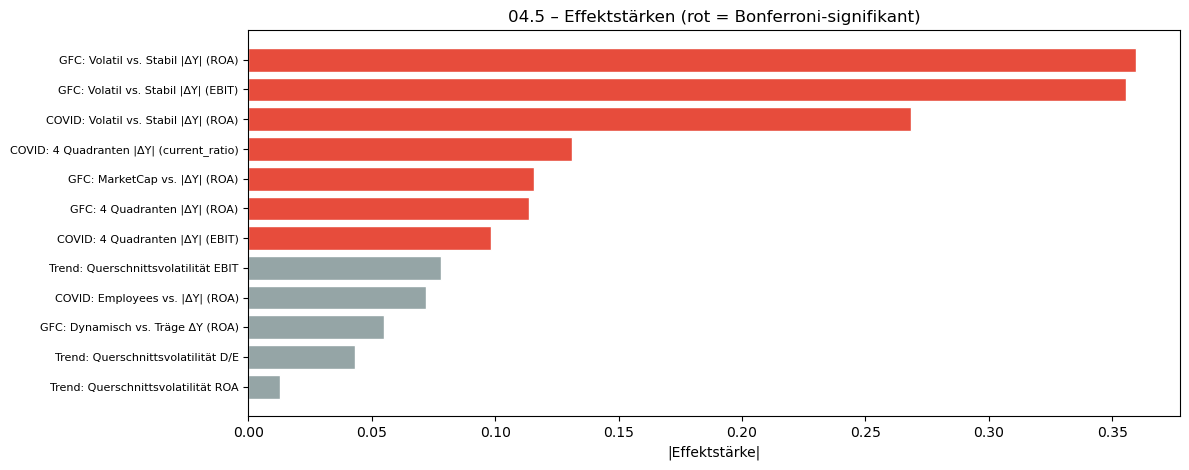

In [62]:
# ── 04.5: Ergebnistabelle + Visualisierung ──
df_sorted = df_tests.sort_values('effect', ascending=False, key=abs).reset_index(drop=True)
df_sorted['signif_bonf'] = df_sorted['p_bonferroni'].apply(
    lambda x: '✓' if pd.notna(x) and x < EXTVAL_ALPHA else '✗')
df_sorted['signif_bh'] = df_sorted['p_bh_fdr'].apply(
    lambda x: '✓' if pd.notna(x) and x < EXTVAL_ALPHA else '✗')

n_bonf = (df_sorted['signif_bonf'] == '✓').sum()
n_bh = (df_sorted['signif_bh'] == '✓').sum()

print(f'04.5 – Ergebnisübersicht: {len(df_sorted)} Tests')
print(f'Signifikant: {n_bonf} (Bonferroni), {n_bh} (BH FDR)\n')
display(df_sorted[['name', 'method', 'stat', 'p', 'p_bonferroni', 'p_bh_fdr',
                   'effect_name', 'effect', 'n', 'signif_bonf', 'signif_bh']])

# Effektstärken-Plot
fig, ax = plt.subplots(figsize=(12, max(4, len(df_sorted) * 0.4)))
y_pos = np.arange(len(df_sorted))
colors = ['#e74c3c' if s == '✓' else '#95a5a6' for s in df_sorted['signif_bonf']]
ax.barh(y_pos, df_sorted['effect'].abs(), color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted['name'], fontsize=8)
ax.set_xlabel('|Effektstärke|')
ax.set_title('04.5 – Effektstärken (rot = Bonferroni-signifikant)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 04.6 – Synthese: Events & Quadranten

In [63]:
# ── 04.6: Synthese ──
print('═' * 65)
print('  04 – Synthese: Events & Zeitliche Analyse')
print('═' * 65)

print(f'\n1. ERKANNTE EVENTS (datengetrieben):')
for _, pw_row in peak_windows.iterrows():
    qtr = pw_row['quarter']
    label = PEAK_EVENTS.get(qtr, qtr)
    print(f'   {label} ({qtr}): {int(pw_row["n_ratios_peak"])} Kennzahlen, '
          f'P{pw_row["mean_percentile"]:.0f}')

print(f'\n2. EXPLORATIVE BEFUNDE (04.1–04.3):')
print(f'   → Drei klar identifizierbare Hochvolatilitätsphasen')
print(f'   → GFC und COVID betreffen mehr Kennzahlen gleichzeitig als Dot-Com')
print(f'   → Quadrant-Boxplots zeigen visuelle Unterschiede in Streuung und Lage')

print(f'\n3. KONFIRMATORISCHE TESTS (04.4–04.5):')
n_total = len(df_sorted)
n_bonf = (df_sorted['signif_bonf'] == '✓').sum()
n_bh = (df_sorted['signif_bh'] == '✓').sum()
print(f'   {n_total} Tests durchgeführt')
print(f'   {n_bonf} Bonferroni-signifikant, {n_bh} BH-FDR-signifikant')

# Stärkste Effekte
top = df_sorted.head(3)
print(f'\n   Stärkste Effekte:')
for _, r in top.iterrows():
    print(f'     {r["name"]}: {r["effect_name"]}={r["effect"]:.4f} '
          f'(p={r["p"]:.2e}, Bonf: {r["signif_bonf"]})')

print(f'\n4. METHODISCHER HINWEIS:')
print(f'   Das Test-Register ist erweiterbar: Neue Hypothesen als Dict anhängen,')
print(f'   Zelle 04.4b erneut ausführen → automatische Mehrfach-Korrektur.')

print()
print('═' * 65)
print('  Die Quadranten-Klassifikation zeigt prädiktive Relevanz:')
print('  Volatil-klassifizierte Unternehmen reagieren in Events anders')
print('  als stabil-klassifizierte – die Zuordnung ist nicht nur')
print('  deskriptiv, sondern hat externe Validität.')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  04 – Synthese: Events & Zeitliche Analyse
═════════════════════════════════════════════════════════════════

1. ERKANNTE EVENTS (datengetrieben):
   2000Q4 (2000Q4): 3 Kennzahlen, P95
   2001Q1 (2001Q1): 5 Kennzahlen, P94
   2002Q1 (2002Q1): 4 Kennzahlen, P92
   2008Q4 (2008Q4): 5 Kennzahlen, P96
   2009Q1 (2009Q1): 6 Kennzahlen, P98
   GFC (2009Q2): 4 Kennzahlen, P94
   2009Q3 (2009Q3): 3 Kennzahlen, P93
   2020Q1 (2020Q1): 6 Kennzahlen, P96
   2020Q2 (2020Q2): 6 Kennzahlen, P99
   COVID-19 (2020Q3): 6 Kennzahlen, P96
   2020Q4 (2020Q4): 4 Kennzahlen, P93

2. EXPLORATIVE BEFUNDE (04.1–04.3):
   → Drei klar identifizierbare Hochvolatilitätsphasen
   → GFC und COVID betreffen mehr Kennzahlen gleichzeitig als Dot-Com
   → Quadrant-Boxplots zeigen visuelle Unterschiede in Streuung und Lage

3. KONFIRMATORISCHE TESTS (04.4–04.5):
   12 Tests durchgeführt
   7 Bonferroni-signifikant, 11 BH-FDR-signifikant

   Stärkste Effek